# PHISH-GLOBE

### A Leakage-Controlled, Multilingual, LLM-Aware Framework for Phishing Detection under Generative Distribution Shift

This notebook implements **50 numbered components (1–50)**, each closing a stated limitation of the
reviewed literature. Every novelty produces a table or figure that can be cited directly in the paper.

| Part | Components | Theme |
|---|---|---|
| I | 1–10 | Corpus integrity, leakage control, provenance |
| II | 11–17 | Language-agnostic representation |
| III | 18–26 | Detection models (classical, neural, transformer) |
| IV | 27–33 | Generative distribution shift |
| V | 34–38 | Adversarial and obfuscation robustness |
| VI | 39–43 | Calibration, cost, deployment operating points |
| VII | 44–47 | Explainability and cross-lingual fairness |
| VIII | 48–50 | Statistical rigour, efficiency, reproducibility |

**Run order:** execute cells top to bottom. Set `FAST_MODE = False` in the configuration cell for the
full-scale run used in the paper.

## Setup

In [1]:
import os, re, gc, io, sys, json, time, math, glob, shutil, zipfile, hashlib, platform, warnings, unicodedata, resource
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import norm

from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             matthews_corrcoef, balanced_accuracy_score, brier_score_loss,
                             roc_curve, precision_recall_curve)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3, "savefig.bbox": "tight"})

In [2]:
FAST_MODE = True

CFG = dict(
    CAP_PER_FILE      = 2500 if FAST_MODE else None,
    MAX_DOC_CHARS     = 8000,
    SEEDS             = [42, 202, 777],
    N_PERM            = 48,
    LSH_BANDS         = 12,
    MAX_WORD_FEATS    = 60000  if FAST_MODE else 200000,
    MAX_CHAR_FEATS    = 2 ** 17 if FAST_MODE else 2 ** 19,
    NEURAL_EPOCHS     = 8      if FAST_MODE else 16,
    ADV_SAMPLE        = 2000   if FAST_MODE else 8000,
    EPS_GRID          = [0.05, 0.10, 0.20, 0.40],
    COST_FN           = 10.0,
    COST_FP           = 1.0,
    OUTDIR            = "phishglobe_artifacts",
)

SEED = CFG["SEEDS"][0]
np.random.seed(SEED)
os.makedirs(CFG["OUTDIR"], exist_ok=True)
os.makedirs(os.path.join(CFG["OUTDIR"], "figures"), exist_ok=True)
os.makedirs(os.path.join(CFG["OUTDIR"], "tables"), exist_ok=True)

T0 = time.time()
TABLES, FIGURES, TIMING = {}, {}, {}


def stamp(msg):
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
    print("[%7.1fs | %5.0f MB] %s" % (time.time() - T0, rss, msg), flush=True)


def register(key, obj):
    TABLES[key] = obj
    obj.to_csv(os.path.join(CFG["OUTDIR"], "tables", key + ".csv"))
    return obj


def savefig(key):
    p = os.path.join(CFG["OUTDIR"], "figures", key + ".png")
    plt.savefig(p)
    FIGURES[key] = p
    plt.show()

stamp("configuration loaded | FAST_MODE=%s" % FAST_MODE)

[    0.0s |   252 MB] configuration loaded | FAST_MODE=True


Locate the dataset. The cell mounts Google Drive when running in Colab, then searches
recursively for the folder holding the dataset CSVs. Folder naming and nesting do not matter —
`NS DATASET`, `NS Dataset` and `Network Security/NS Dataset` all resolve. If automatic detection
fails, set `DATA_ROOT` by hand in the next cell.

In [3]:
MARKERS = ("_clean_unique.csv", "clean_dataset.csv", "clean_separate.csv", "master_dataset.csv")


def _mount_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir("/content/drive/MyDrive"):
        try:
            drive.mount("/content/drive")
        except Exception as e:
            print("Drive mount skipped:", e)


def _score(path):
    try:
        names = [n.lower() for n in os.listdir(path)]
    except OSError:
        return 0
    return sum(1 for n in names if n.endswith(MARKERS))


def _walk(root, max_depth=5):
    root = os.path.abspath(root)
    base = root.rstrip(os.sep).count(os.sep)
    out = []
    for cur, dirs, _ in os.walk(root):
        if cur.count(os.sep) - base >= max_depth:
            dirs[:] = []
        dirs[:] = [d for d in dirs if not d.startswith((".", "__")) and d != "node_modules"]
        n = _score(cur)
        if n:
            out.append((n, cur))
    return out


def locate_dataset(extra=()):
    _mount_drive()
    roots = list(extra) + ["/content/drive/MyDrive", "/content", ".", "data_raw",
                           "/mnt/user-data/uploads", os.path.expanduser("~")]
    hits = {}
    for r in roots:
        if os.path.isdir(r):
            for n, p in _walk(r):
                hits[os.path.realpath(p)] = n
    if not hits:
        for z in glob.glob("**/Network_Security_Dataset.zip", recursive=True) + \
                 ["/content/Network_Security_Dataset.zip"]:
            if os.path.exists(z):
                dest = "/content/nsdata" if os.path.isdir("/content") else "nsdata"
                zipfile.ZipFile(z).extractall(dest)
                for n, p in _walk(dest):
                    hits[os.path.realpath(p)] = n
                break
    if not hits:
        return None, []
    ranked = sorted(hits.items(), key=lambda kv: -kv[1])
    return ranked[0][0], ranked


DATA_ROOT, CANDIDATES = locate_dataset()

if len(CANDIDATES) > 1:
    print("Candidate folders found:")
    for pth, n in CANDIDATES:
        print("   %2d dataset files  %s" % (n, pth))
    print()

assert DATA_ROOT, ("Dataset not found. Set DATA_ROOT manually, e.g.\n"
                   "  DATA_ROOT = '/content/drive/MyDrive/Network Security/NS Dataset'")

print("DATA_ROOT =", DATA_ROOT)
found = sorted(os.path.basename(x) for x in glob.glob(os.path.join(DATA_ROOT, "*.csv")))
print("%d CSV files:" % len(found))
for f in found:
    print("   ", f)

Mounted at /content/drive
DATA_ROOT = /content/drive/MyDrive/Network Security/NS Dataset
12 CSV files:
    AI_MULTILINGUAL_CLEAN_DATASET.csv
    BangalaBarta_Clean_Unique.csv
    CEAS_08_Clean_Unique.csv
    Enron_Clean_Unique.csv
    LLM_GENERATED_CLEAN_SEPARATE.csv
    Ling_Clean_Unique.csv
    Multilingual_EN_HI_DE_FR_Clean_Unique.csv
    Nazario_Clean_Unique.csv
    Nigerian_Fraud_Clean_Unique.csv
    Phishing_Email_Clean_Unique.csv
    REAL_DATA_MASTER_DATASET.csv
    SpamAssasin_Clean_Unique.csv


Reading 150 MB of CSVs directly from mounted Drive is slow and the connection can drop
mid-run. This cell copies the folder to local Colab storage once, which takes about a minute and
makes every subsequent read fast. It is skipped automatically outside Colab.

In [4]:
if DATA_ROOT.startswith("/content/drive"):
    LOCAL = "/content/ns_local"
    if not (os.path.isdir(LOCAL) and _score(LOCAL) >= _score(DATA_ROOT)):
        os.makedirs(LOCAL, exist_ok=True)
        t = time.time()
        for f in glob.glob(os.path.join(DATA_ROOT, "*")):
            if os.path.isfile(f):
                shutil.copy2(f, LOCAL)
        print("copied to local storage in %.1fs" % (time.time() - t))
    DATA_ROOT = LOCAL
    print("DATA_ROOT =", DATA_ROOT)
else:
    print("not on Drive; using DATA_ROOT as-is:", DATA_ROOT)

copied to local storage in 19.8s
DATA_ROOT = /content/ns_local


## Part I: Corpus Integrity, Leakage Control and Provenance (1–10)

### 1. Provenance-tracked unified multilingual corpus

**Closes:** All 18 reviewed works evaluate on a single corpus with no per-record provenance, so corpus-specific artefacts cannot be separated from genuine phishing signal.

In [5]:
HUMAN_FILES = {
    "CEAS_08_Clean_Unique.csv":                  ("CEAS_08",          "email", "Kaggle/Al-Subaiey"),
    "Enron_Clean_Unique.csv":                    ("Enron",            "email", "Kaggle/Al-Subaiey"),
    "Ling_Clean_Unique.csv":                     ("Ling",             "email", "Kaggle/Al-Subaiey"),
    "Nazario_Clean_Unique.csv":                  ("Nazario",          "email", "Kaggle/Al-Subaiey"),
    "Nigerian_Fraud_Clean_Unique.csv":           ("Nigerian_Fraud",   "email", "Kaggle/Al-Subaiey"),
    "SpamAssasin_Clean_Unique.csv":              ("SpamAssassin",     "email", "Kaggle/Al-Subaiey"),
    "BangalaBarta_Clean_Unique.csv":             ("BangalaBarta",     "sms",   "Mendeley 10.17632/jfkfbw3gzh.2"),
    "Multilingual_EN_HI_DE_FR_Clean_Unique.csv": ("Multilingual_SMS", "sms",   "Kaggle/Patel (UCI SMS)"),
}
LLM_FILES = {
    "AI_MULTILINGUAL_CLEAN_DATASET.csv":  ("E-PhishLLM",       "email", "E-PhishGEN arXiv:2509.01791"),
    "LLM_GENERATED_CLEAN_SEPARATE.csv":   ("LLM_Unattributed", "email", "unattributed"),
}
SUPERSET_FILE = "Phishing_Email_Clean_Unique.csv"

POS = {"phishing": 1.0, "spam": 1.0, "smishing": 1.0}
NEG = {"legitimate": 0.0, "ham": 0.0, "normal": 0.0}


def _text_of(df):
    if "text" in df.columns:
        return df["text"].astype(str)
    s = df["subject"].astype(str) if "subject" in df.columns else None
    b = df["body"].astype(str) if "body" in df.columns else None
    if s is not None and b is not None:
        return s + " \n " + b
    return b if b is not None else s


def _label_of(df):
    for c in ["standard_label", "label"]:
        if c not in df.columns:
            continue
        s = df[c]
        if pd.api.types.is_numeric_dtype(s):
            return pd.to_numeric(s, errors="coerce").astype(float)
        m = s.astype("object").astype(str).str.strip().str.lower()
        out = m.map({**POS, **NEG}).astype(float)
        if out.notna().any():
            return out
        n = pd.to_numeric(m, errors="coerce")
        if n.notna().any():
            return n.astype(float)
    return pd.Series(np.nan, index=df.index, dtype=float)


def load_corpus(root, cap=None):
    frames = []
    for fn, (src, ch, prov) in list(HUMAN_FILES.items()) + list(LLM_FILES.items()):
        p = os.path.join(root, fn)
        if not os.path.exists(p):
            continue
        df = pd.read_csv(p, encoding="utf-8-sig", low_memory=False)
        if cap and len(df) > cap:
            df = df.sample(cap, random_state=SEED)
        frames.append(pd.DataFrame({
            "text": _text_of(df),
            "y": _label_of(df),
            "source": src,
            "channel": ch,
            "provenance": prov,
            "origin": "LLM" if fn in LLM_FILES else "HUMAN",
            "lang_declared": df["language"].astype(str) if "language" in df.columns else "unknown",
        }))
    c = pd.concat(frames, ignore_index=True)
    c = c[c["y"].notna()].copy()
    c["y"] = c["y"].astype(int)
    c["text"] = c["text"].astype(str).str.strip().str.slice(0, CFG["MAX_DOC_CHARS"])
    return c[c["text"].str.len() >= 3].reset_index(drop=True)


stamp("loading corpus")
corpus = load_corpus(DATA_ROOT, CFG["CAP_PER_FILE"])

T1 = (corpus.groupby(["origin", "channel", "source", "provenance"])
        .agg(records=("y", "size"), phishing_rate=("y", "mean")).round(4).reset_index())
T1.loc[len(T1)] = ["TOTAL", "", "", "", len(corpus), round(corpus["y"].mean(), 4)]
register("corpus_provenance", T1)
display(T1)

[   53.2s |   252 MB] loading corpus


,origin,channel,source,provenance,records,phishing_rate
0,HUMAN,email,CEAS_08,Kaggle/Al-Subaiey,2500,0.5472
1,HUMAN,email,Enron,Kaggle/Al-Subaiey,2500,0.4912
2,HUMAN,email,Ling,Kaggle/Al-Subaiey,2500,0.1620
3,HUMAN,email,Nazario,Kaggle/Al-Subaiey,1526,1.0000
4,HUMAN,email,Nigerian_Fraud,Kaggle/Al-Subaiey,2500,1.0000
5,HUMAN,email,SpamAssassin,Kaggle/Al-Subaiey,2500,0.2864
6,HUMAN,sms,BangalaBarta,Mendeley 10.17632/jfkfbw3gzh.2,959,0.5422
7,HUMAN,sms,Multilingual_SMS,Kaggle/Patel (UCI SMS),2500,0.1320
8,LLM,email,E-PhishLLM,E-PhishGEN arXiv:2509.01791,2500,0.4880
9,LLM,email,LLM_Unattributed,unattributed,1161,0.1404


### 2. Detection and removal of the superset-redundancy trap

**Closes:** `phishing_email.csv` in the Kaggle collection is the concatenation of the other six subsets. Studies that combine it with its own components silently duplicate every record and inflate results.

In [6]:
stamp("superset redundancy audit")

def csv_rows(path):
    n = 0
    for ch in pd.read_csv(path, encoding="utf-8-sig", usecols=[0], chunksize=200000, low_memory=False):
        n += len(ch)
    return n


parts = [f for f in HUMAN_FILES if HUMAN_FILES[f][2].startswith("Kaggle/Al-Subaiey")]
rows, total = [], 0
for f in parts:
    p = os.path.join(DATA_ROOT, f)
    if os.path.exists(p):
        n = csv_rows(p)
        rows.append({"file": f.replace("_Clean_Unique.csv", ""), "rows": n})
        total += n

sup_path = os.path.join(DATA_ROOT, SUPERSET_FILE)
sup_n = csv_rows(sup_path) if os.path.exists(sup_path) else 0

T2 = pd.DataFrame(rows)
T2.loc[len(T2)] = {"file": "SUM OF COMPONENTS", "rows": total}
T2.loc[len(T2)] = {"file": "phishing_email (superset)", "rows": sup_n}
T2.loc[len(T2)] = {"file": "REDUNDANCY OVERLAP %",
                       "rows": round(100 * min(total, sup_n) / max(total, sup_n, 1), 2)}
register("superset_redundancy", T2)
display(T2)
print("\nEXCLUDED from all experiments:", SUPERSET_FILE)

[   56.9s |   400 MB] superset redundancy audit


,file,rows
0,CEAS_08,38359.00
1,Enron,29360.00
2,Ling,2859.00
3,Nazario,1526.00
4,Nigerian_Fraud,3270.00
5,SpamAssasin,5784.00
6,SUM OF COMPONENTS,81158.00
7,phishing_email (superset),82077.00
8,REDUNDANCY OVERLAP %,98.88



EXCLUDED from all experiments: Phishing_Email_Clean_Unique.csv


### 3. Near-duplicate suppression via MinHash-LSH and the NDCI

**Closes:** Every reviewed study deduplicates by exact string match only. Forwarded, quoted and templated messages survive as near-duplicates and leak across the train/test boundary.

In [7]:
stamp("near-duplicate LSH")

def _shingles(t, k=5):
    t = re.sub(r"\s+", " ", t.lower())[:3000]
    return {t} if len(t) <= k else {t[i:i + k] for i in range(0, len(t) - k + 1, 2)}


def _signature(t, perms, k=5):
    sh = _shingles(t, k)
    if not sh:
        return np.full(perms.shape[0], np.iinfo(np.int64).max, dtype=np.int64)
    h = np.fromiter((int(hashlib.blake2b(s.encode("utf8"), digest_size=8).hexdigest(), 16) & 0x7FFFFFFF
                     for s in sh), dtype=np.int64, count=len(sh))
    return ((perms[:, 0][:, None] * h[None, :] + perms[:, 1][:, None]) % 2147483647).min(axis=1)


def near_duplicate_groups(texts, n_perm, bands, seed=SEED):
    rs = np.random.RandomState(seed)
    perms = np.stack([rs.randint(1, 2147483646, n_perm), rs.randint(0, 2147483646, n_perm)], axis=1)
    sigs = np.vstack([_signature(t, perms) for t in texts])
    parent = np.arange(len(texts))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    rowsz = n_perm // bands
    for bi in range(bands):
        buckets = defaultdict(list)
        blk = sigs[:, bi * rowsz:(bi + 1) * rowsz]
        for i in range(len(texts)):
            buckets[blk[i].tobytes()].append(i)
        for idxs in buckets.values():
            if len(idxs) > 1:
                r0 = find(idxs[0])
                for j in idxs[1:]:
                    rj = find(j)
                    if r0 != rj:
                        parent[max(r0, rj)] = min(r0, rj)
                        r0 = min(r0, rj)
    return np.array([find(i) for i in range(len(texts))])


corpus["dupgroup"] = near_duplicate_groups(corpus["text"].tolist(), CFG["N_PERM"], CFG["LSH_BANDS"])
n_rec, n_grp = len(corpus), corpus["dupgroup"].nunique()
NDCI = 100.0 * (1 - n_grp / n_rec)

T3 = pd.DataFrame({"metric": ["records", "distinct near-duplicate groups",
                                "collapsed records", "NDCI (%)"],
                     "value": [n_rec, n_grp, n_rec - n_grp, round(NDCI, 3)]})
register("near_duplicate_index", T3)
display(T3)
display(corpus.groupby("source")["dupgroup"].agg(
    records="size", groups="nunique").assign(
    NDCI_pct=lambda d: (100 * (1 - d.groups / d.records)).round(2)).sort_values("NDCI_pct", ascending=False))

[   60.8s |   552 MB] near-duplicate LSH


,metric,value
0,records,21146.000
1,distinct near-duplicate groups,17751.000
2,collapsed records,3395.000
3,NDCI (%),16.055


,records,groups,NDCI_pct
source,,,
Nigerian_Fraud,2500,1604,35.84
LLM_Unattributed,1161,827,28.77
BangalaBarta,959,718,25.13
Nazario,1526,1191,21.95
CEAS_08,2500,1983,20.68
SpamAssassin,2500,2197,12.12
Enron,2500,2269,9.24
E-PhishLLM,2500,2295,8.20
Ling,2500,2358,5.68


### 4. Translation-group leakage barrier

**Closes:** The EN/HI/DE/FR subset was produced by machine-translating one English corpus, so each message appears up to four times with no shared identifier and no shared surface form across scripts. A random split places translations of the same message on both sides of the boundary.

In [8]:
stamp("translation-group barrier")
mask = (corpus["source"] == "Multilingual_SMS").values


def _digits(t):
    return tuple(sorted(set(re.findall(r"\d{4,}", str(t)))))


def align_translations(df, ref_lang="English", lookahead=6):
    d = df.copy()
    d["_dig"] = d["text"].map(_digits)
    d["_lab"] = d["y"].astype(str)
    langs = d["lang_declared"].astype(str)
    d["_lg"] = np.where(langs.isin(["English", "Hindi", "German", "French"]), langs, "Other")
    ref = d[d["_lg"] == ref_lang]
    if len(ref) == 0:
        return pd.factorize(d["text"].str.slice(0, 24))[0]

    gid = pd.Series(-1, index=d.index, dtype=int)
    gid.loc[ref.index] = np.arange(len(ref))
    rlab, rdig = ref["_lab"].values, ref["_dig"].values

    for lg in [x for x in d["_lg"].unique() if x != ref_lang]:
        blk = d[d["_lg"] == lg]
        i = 0
        for j, idx in enumerate(blk.index):
            lab, dg = blk["_lab"].iat[j], blk["_dig"].iat[j]
            best = None
            for k in range(i, min(i + lookahead, len(ref))):
                sc = (1 if rlab[k] == lab else 0) + (3 if dg and rdig[k] == dg else 0)
                if sc > 0 and (best is None or sc > best[0]):
                    best = (sc, k)
                if sc == 4:
                    break
            k = best[1] if best else min(i, len(ref) - 1)
            gid.iat[d.index.get_loc(idx)] = k
            i = k + 1
    return gid.values


if mask.any():
    sub = corpus.loc[mask]
    tg = align_translations(sub)
    corpus.loc[mask, "dupgroup"] = corpus["dupgroup"].max() + 1 + tg

corpus["group"] = corpus["dupgroup"].astype(int)

if mask.any():
    chk = corpus.loc[mask].groupby("group")["y"].nunique()
    naive = corpus.loc[mask].copy()
    naive["_pos"] = naive.groupby("lang_declared").cumcount()
    nb = naive.groupby("_pos")["y"].nunique()
    T4 = pd.DataFrame({
        "metric": ["translated records", "aligned translation groups",
                   "mean translations per group", "groups spanning all 4 languages",
                   "label-consistent groups (%)", "naive positional baseline (%)",
                   "final leakage groups (whole corpus)"],
        "value": [int(mask.sum()), int(chk.size),
                  round(mask.sum() / max(chk.size, 1), 2),
                  int((corpus.loc[mask].groupby("group")["lang_declared"].nunique() == 4).sum()),
                  round(100 * (chk == 1).mean(), 1),
                  round(100 * (nb == 1).mean(), 1),
                  int(corpus["group"].nunique())]})
else:
    T4 = pd.DataFrame({"metric": ["translated records"], "value": [0]})

register("translation_barrier", T4)
display(T4)
print("Alignment uses preserved numeric anchors plus label agreement with bounded lookahead,")
print("because translations share no surface form across Latin, Devanagari and Bengali scripts.")

[  114.3s |   552 MB] translation-group barrier


,metric,value
0,translated records,2500.00
1,aligned translation groups,640.00
2,mean translations per group,3.91
3,groups spanning all 4 languages,371.00
4,label-consistent groups (%),87.80
5,naive positional baseline (%),58.40
6,final leakage groups (whole corpus),15915.00


Alignment uses preserved numeric anchors plus label agreement with bounded lookahead,
because translations share no surface form across Latin, Devanagari and Bengali scripts.


### 5. Mail-transport boilerplate scrubbing

**Closes:** Raw mbox headers survive in the Nazario and SpamAssassin subsets. `Received:`, `Return-Path:` and `X-*` lines are perfectly correlated with the source corpus and give a model a free shortcut.

In [9]:
stamp("boilerplate scrubbing")
HDR = re.compile(r"(?im)^\s*(received|return-path|delivered-to|x-[\w-]+|message-id|mime-version|"
                 r"content-type|content-transfer-encoding|dkim-signature|authentication-results|"
                 r"arc-[\w-]+|list-[\w-]+|precedence|user-agent|in-reply-to|references|"
                 r"resent-[\w-]+|envelope-to|domainkey-signature)\s*:.*$")
MBOX = re.compile(r"(?m)^From\s+\S+@\S+\s+\w{3}\s+\w{3}\s+\d+.*$")
BND = re.compile(r"--[-_=]{2,}[A-Za-z0-9_=.]{6,}")
NOISE = re.compile(r"(?i)(don'?t delete this message\s*--\s*folder internal data|"
                   r"this text is part of the internal format of your mail folder)")


def scrub(t):
    t = MBOX.sub(" ", t)
    t = HDR.sub(" ", t)
    t = BND.sub(" ", t)
    t = NOISE.sub(" ", t)
    t = re.sub(r"=\r?\n", "", t)
    t = re.sub(r"=[0-9A-F]{2}", " ", t)
    t = re.sub(r"<[^>]{1,400}>", " ", t)
    t = re.sub(r"&[a-z]{2,8};", " ", t)
    return re.sub(r"\s+", " ", t).strip()


before = corpus.groupby("source")["text"].apply(lambda s: s.str.len().mean())
corpus["text"] = [scrub(t) for t in corpus["text"]]
corpus = corpus[corpus["text"].str.len() >= 3].reset_index(drop=True)
after = corpus.groupby("source")["text"].apply(lambda s: s.str.len().mean())

T5 = pd.DataFrame({"mean_chars_before": before, "mean_chars_after": after})
T5["removed_pct"] = (100 * (1 - T5.mean_chars_after / T5.mean_chars_before)).round(2)
register("boilerplate_scrub", T5.round(1))
display(T5.round(1).sort_values("removed_pct", ascending=False))

[  114.9s |   552 MB] boilerplate scrubbing


,mean_chars_before,mean_chars_after,removed_pct
source,,,
Nazario,1174.2,1082.2,7.8
SpamAssassin,1777.2,1671.4,6.0
CEAS_08,1416.7,1349.7,4.7
Enron,1344.5,1320.0,1.8
Nigerian_Fraud,2604.7,2559.6,1.7
E-PhishLLM,623.3,614.4,1.4
Multilingual_SMS,83.6,83.2,0.5
Ling,2866.8,2857.8,0.3
BangalaBarta,79.2,79.1,0.1


### 6. Corpus Fingerprint Leakage Index (CFLI)

**Closes:** No reviewed study measures how much of its accuracy comes from recognising which corpus a message was drawn from rather than whether it is phishing. CFLI makes that confound measurable for the first time.

In [10]:
stamp("corpus fingerprint leakage index")
probe_vec = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xp = probe_vec.fit_transform(corpus["text"])
src_codes, src_names = pd.factorize(corpus["source"])

acc, base = [], []
for tr, te in StratifiedKFold(3, shuffle=True, random_state=SEED).split(Xp, src_codes):
    m = LogisticRegression(max_iter=400).fit(Xp[tr], src_codes[tr])
    acc.append(accuracy_score(src_codes[te], m.predict(Xp[te])))
    base.append(pd.Series(src_codes[te]).value_counts(normalize=True).max())

a, b = float(np.mean(acc)), float(np.mean(base))
CFLI = (a - b) / (1 - b)
T6 = pd.DataFrame({"metric": ["corpus-identification accuracy", "majority-class baseline",
                                "CFLI (0 = no fingerprint, 1 = fully separable)"],
                     "value": [round(a, 4), round(b, 4), round(CFLI, 4)]})
register("corpus_fingerprint_leakage", T6)
display(T6)
print("Interpretation: a CFLI of %.2f means source corpus is recoverable from text alone;" % CFLI)
print("headline single-corpus accuracies must therefore be discounted against cross-corpus results.")
del Xp, probe_vec
gc.collect()

[  133.9s |   552 MB] corpus fingerprint leakage index


,metric,value
0,corpus-identification accuracy,0.9274
1,majority-class baseline,0.1183
2,"CFLI (0 = no fingerprint, 1 = fully separable)",0.9176


Interpretation: a CFLI of 0.92 means source corpus is recoverable from text alone;
headline single-corpus accuracies must therefore be discounted against cross-corpus results.


87

### 7. Out-of-fold confident-learning label audit

**Closes:** Reviewed studies treat published labels as ground truth. The unattributed LLM subset in this dataset contains account-verification phishing text labelled *legitimate*; unaudited noise caps achievable recall.

In [11]:
stamp("label audit")
audit_vec = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xa = audit_vec.fit_transform(corpus["text"])
ya = corpus["y"].values
oof = np.zeros(len(corpus))
for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xa, ya):
    oof[te] = LogisticRegression(max_iter=400, C=4.0).fit(Xa[tr], ya[tr]).predict_proba(Xa[te])[:, 1]

corpus["label_risk"] = np.where(ya == 1, 1 - oof, oof)
thr = np.quantile(corpus["label_risk"], 0.99)
corpus["label_suspect"] = corpus["label_risk"] >= thr

T7 = (corpus.groupby("source")
        .agg(records=("y", "size"), suspect=("label_suspect", "sum"),
             mean_label_risk=("label_risk", "mean"))
        .assign(suspect_rate_pct=lambda d: (100 * d.suspect / d.records).round(2))
        .sort_values("suspect_rate_pct", ascending=False).round(4))
register("label_audit", T7)
display(T7)
print("\nHighest-risk examples:")
for _, r in corpus.nlargest(4, "label_risk")[["source", "y", "text"]].iterrows():
    print("  [%s | label=%d] %s..." % (r["source"], r["y"], r["text"][:110]))
del Xa, audit_vec
gc.collect()

[  201.9s |   789 MB] label audit


,records,suspect,mean_label_risk,suspect_rate_pct
source,,,,
Multilingual_SMS,2500,54,0.1696,2.16
BangalaBarta,959,18,0.1735,1.88
Enron,2500,40,0.1246,1.60
CEAS_08,2500,30,0.0984,1.20
E-PhishLLM,2500,30,0.1350,1.20
LLM_Unattributed,1161,11,0.1113,0.95
SpamAssassin,2500,19,0.0725,0.76
Nazario,1526,3,0.0567,0.20
Nigerian_Fraud,2500,4,0.0244,0.16



Highest-risk examples:
  [CEAS_08 | label=0] CNN Alerts: bush CNN Alerts: bush Alert Name: bush Self-deportation program kicks off with few takers 08/06/08...
  [E-PhishLLM | label=1] Urgent: Marketing Report for Upcoming Event Dear Olivia, I hope this email finds you well. I am reaching out t...
  [SpamAssassin | label=0] Announcing the New Netscape 7.0 - The Fastest Netscape Browser Ever This is a multi-part message in MIME forma...
  [Multilingual_SMS | label=1] LIFE war noch nie so viel Spaß und toll, bis du reingekommen bist. Du hast es wirklich speziell für mich gemac...


145

### 8. Deterministic Unicode-block language re-identification

**Closes:** The shipped `language` column was produced by a statistical detector and reports 10 languages for a 3-language corpus. Per-language reporting (item 45) requires labels that are actually correct.

In [12]:
stamp("language re-identification")
BLOCKS = [("Bengali", 0x0980, 0x09FF), ("Devanagari", 0x0900, 0x097F), ("Arabic", 0x0600, 0x06FF),
          ("Cyrillic", 0x0400, 0x04FF), ("CJK", 0x4E00, 0x9FFF), ("Greek", 0x0370, 0x03FF),
          ("Hangul", 0xAC00, 0xD7AF), ("Thai", 0x0E00, 0x0E7F), ("Hebrew", 0x0590, 0x05FF)]
STOP = {
 "English": {"the","and","you","for","that","with","your","this","have","from","not","are","will"},
 "German":  {"der","die","das","und","ist","nicht","sie","mit","für","ein","eine","auch","wir"},
 "French":  {"le","la","les","de","et","est","une","pour","vous","dans","que","des","nous"},
 "Italian": {"il","la","di","che","per","non","una","con","sono","come","nostro","questo","alla"},
 "Spanish": {"el","la","de","que","los","para","con","una","por","como","más","este","son"},
}
WORD = re.compile(r"[a-zà-öø-ÿ]+")


def script_profile(t, cap=4000):
    counts = defaultdict(int)
    for ch in t[:cap]:
        o = ord(ch)
        for name, lo, hi in BLOCKS:
            if lo <= o <= hi:
                counts[name] += 1
                break
        else:
            if 0x41 <= o <= 0x5A or 0x61 <= o <= 0x7A or 0xC0 <= o <= 0x24F:
                counts["Latin"] += 1
    return counts


def identify_language(t):
    c = script_profile(t)
    tot = sum(c.values()) or 1
    for name in [b[0] for b in BLOCKS]:
        if c.get(name, 0) / tot > 0.20:
            return {"Bengali": "Bangla", "Devanagari": "Hindi"}.get(name, name)
    toks = set(WORD.findall(t.lower()[:4000]))
    if not toks:
        return "Unknown"
    best, score = "English", -1
    for lg, sw in STOP.items():
        s = len(toks & sw)
        if s > score:
            best, score = lg, s
    return best if score > 0 else "English"


corpus["lang"] = [identify_language(t) for t in corpus["text"]]
T8 = pd.crosstab(corpus["lang_declared"].astype(str).str.slice(0, 16), corpus["lang"])
register("language_reidentification", T8)
display(T8)
display(corpus["lang"].value_counts().rename("records").to_frame())

[  220.2s |   809 MB] language re-identification


lang,Arabic,Bangla,CJK,Cyrillic,English,French,German,Greek,Hangul,Hebrew,Hindi,Italian,Spanish,Unknown
lang_declared,,,,,,,,,,,,,,
Bangla,0,954,0,0,4,1,0,0,0,0,0,0,0,0
English,2,0,31,4,15596,104,30,1,3,2,0,15,38,1
French,0,0,0,0,119,479,0,0,0,0,0,15,0,0
German,0,0,0,0,169,1,426,0,0,0,0,0,0,0
Hindi,0,0,0,0,4,0,0,0,0,0,647,0,0,0
de,0,0,0,0,0,0,343,0,0,0,0,0,0,0
en,0,0,0,0,1753,0,0,0,0,0,0,0,0,0
es,0,0,0,0,0,0,0,0,0,0,0,0,6,0
fr,0,0,0,0,0,3,0,0,0,0,0,0,0,0


,records
lang,
English,17646
Bangla,954
German,799
Hindi,647
French,589
Italian,422
Spanish,44
CJK,32
Cyrillic,4


### 9. Group-stratified train / validation / test partition

**Closes:** Random splitting is used throughout the reviewed literature. Here the split is stratified jointly on label x language x corpus and constrained so no near-duplicate or translation group is ever split.

In [13]:
stamp("group-stratified split")
human = corpus[corpus["origin"] == "HUMAN"].reset_index(drop=True)
llm    = corpus[corpus["origin"] == "LLM"].reset_index(drop=True)

strat = human["y"].astype(str) + "|" + human["lang"] + "|" + human["source"]
strat = strat.where(strat.map(strat.value_counts()) >= 6, "rare")

outer = StratifiedGroupKFold(5, shuffle=True, random_state=SEED)
rest_i, test_i = next(iter(outer.split(human, strat, groups=human["group"])))
sub, sub_s = human.iloc[rest_i].reset_index(drop=True), strat.iloc[rest_i].reset_index(drop=True)
inner = StratifiedGroupKFold(8, shuffle=True, random_state=SEED)
tr_i, va_i = next(iter(inner.split(sub, sub_s, groups=sub["group"])))

train = sub.iloc[tr_i].reset_index(drop=True)
val   = sub.iloc[va_i].reset_index(drop=True)
test  = human.iloc[test_i].reset_index(drop=True)

for a_, b_ in [("train", "test"), ("train", "val"), ("val", "test")]:
    A = {"train": train, "val": val, "test": test}[a_]
    B = {"train": train, "val": val, "test": test}[b_]
    assert not (set(A["group"]) & set(B["group"])), "group leakage between %s and %s" % (a_, b_)

y_tr, y_va, y_te, y_llm = (d["y"].values for d in (train, val, test, llm))
T9 = pd.DataFrame([{"split": k, "records": len(d), "phishing_rate": round(d["y"].mean(), 4),
                      "languages": d["lang"].nunique(), "corpora": d["source"].nunique(),
                      "leakage_groups": d["group"].nunique()}
                     for k, d in [("train", train), ("validation", val),
                                  ("test (human)", test), ("external (LLM)", llm)]])
register("splits", T9)
display(T9)
print("Group-disjointness verified across all three human splits.")

[  237.4s |   809 MB] group-stratified split


,split,records,phishing_rate,languages,corpora,leakage_groups
0,train,12655,0.4994,14,8,9154
1,validation,1534,0.4681,7,8,1163
2,test (human),3296,0.4718,9,8,2523
3,external (LLM),3661,0.3778,6,2,3103


Group-disjointness verified across all three human splits.


### 10. Cryptographic reproducibility manifest

**Closes:** None of the 18 works publish split-level hashes or an environment capture, so their partitions cannot be reconstructed by a third party.

In [14]:
stamp("reproducibility manifest")

def split_sha(df):
    return hashlib.sha256(pd.util.hash_pandas_object(df["text"], index=False).values.tobytes()).hexdigest()


MANIFEST = {
    "config": {k: str(v) for k, v in CFG.items()},
    "environment": {"python": sys.version.split()[0], "numpy": np.__version__,
                    "pandas": pd.__version__, "platform": platform.platform()},
    "excluded_files": [SUPERSET_FILE],
    "splits": {k: {"n": len(d), "sha256": split_sha(d)}
               for k, d in [("train", train), ("val", val), ("test", test), ("llm_external", llm)]},
}
MANIFEST["config_hash"] = hashlib.sha256(
    json.dumps(MANIFEST["config"], sort_keys=True).encode()).hexdigest()[:16]

with open(os.path.join(CFG["OUTDIR"], "manifest.json"), "w") as f:
    json.dump(MANIFEST, f, indent=2)

T10 = pd.DataFrame([{"split": k, "n": v["n"], "sha256_prefix": v["sha256"][:24]}
                      for k, v in MANIFEST["splits"].items()])
register("manifest", T10)
display(T10)
print("config_hash =", MANIFEST["config_hash"])

[  252.2s |   809 MB] reproducibility manifest


,split,n,sha256_prefix
0,train,12655,a70676dd2d01de3147304a13
1,val,1534,55f90d0040cdf6a3902c3607
2,test,3296,e34461385c192ba6e884f9f0
3,llm_external,3661,96135d0a7e0c6e0fca814dc2


config_hash = 75e0de8f84ca0900


## Part II: Language-Agnostic Representation (11–17)

### 11. Script-agnostic character n-gram hashing channel

**Closes:** Word tokenisation assumes whitespace-delimited Latin script. Rao et al. name language dependence as an explicit limitation. Character n-grams over a hashed space need no tokeniser and cover Bangla and Hindi.

In [15]:
stamp("character channel")
char_vec = HashingVectorizer(analyzer="char_wb", ngram_range=(2, 5),
                             n_features=CFG["MAX_CHAR_FEATS"], alternate_sign=False,
                             norm="l2", lowercase=True)
Xc_tr = char_vec.transform(train["text"])
Xc_va = char_vec.transform(val["text"])
Xc_te = char_vec.transform(test["text"])
Xc_llm = char_vec.transform(llm["text"])
print("character channel:", Xc_tr.shape, "| stateless, no vocabulary, no tokeniser")

[  252.4s |   809 MB] character channel
character channel: (12655, 131072) | stateless, no vocabulary, no tokeniser


### 12. Word-level TF-IDF channel

**Closes:** Retained as the continuity baseline with the reviewed transformer-free literature and with the TF-IDF + Logistic Regression configuration in the original project notebook.

In [16]:
stamp("word channel")
word_vec = TfidfVectorizer(max_features=CFG["MAX_WORD_FEATS"], ngram_range=(1, 2),
                           min_df=2, sublinear_tf=True, lowercase=True)
Xw_tr = word_vec.fit_transform(train["text"])
Xw_va = word_vec.transform(val["text"])
Xw_te = word_vec.transform(test["text"])
Xw_llm = word_vec.transform(llm["text"])
print("word channel:", Xw_tr.shape)

[  296.4s |  1437 MB] word channel
word channel: (12655, 60000)


### 13. Cross-Lingual Social-Engineering Lexicon (CLSEL)

**Closes:** Opara et al. build 60 stylometric features but only for English. CLSEL encodes the five persuasion primitives of phishing across six languages so intent, not vocabulary, drives the feature.

In [17]:
stamp("cross-lingual lexicon")
LEX = {
 "urgency": {
   "English": ["urgent","immediately","asap","expires","act now","today only","last chance","deadline","suspend"],
   "German":  ["dringend","sofort","läuft ab","letzte chance","frist","umgehend"],
   "French":  ["urgent","immédiatement","expire","dernière chance","délai"],
   "Italian": ["urgente","immediatamente","scade","ultima possibilità","scadenza"],
   "Bangla":  ["জরুরি","এখনই","অবিলম্বে","শেষ দিন","আজই"],
   "Hindi":   ["तुरंत","अभी","जल्दी","अंतिम"]},
 "authority": {
   "English": ["bank","security team","administrator","official","department","government","irs","support team"],
   "German":  ["bank","sicherheitsteam","administrator","behörde","amt"],
   "French":  ["banque","administrateur","service de sécurité","officiel"],
   "Italian": ["banca","amministratore","sicurezza","ufficiale"],
   "Bangla":  ["ব্যাংক","কর্তৃপক্ষ","প্রশাসন","সরকার"],
   "Hindi":   ["बैंक","सरकार","प्रशासन"]},
 "reward": {
   "English": ["free","winner","prize","congratulations","bonus","cash","reward","claim","gift"],
   "German":  ["kostenlos","gewinner","preis","glückwunsch","bonus"],
   "French":  ["gratuit","gagnant","prix","félicitations","bonus"],
   "Italian": ["gratis","vincitore","premio","congratulazioni","bonus"],
   "Bangla":  ["ফ্রি","বিজয়ী","পুরস্কার","বোনাস","ছাড়","অফার"],
   "Hindi":   ["मुफ्त","इनाम","बोनस","जीत"]},
 "credential": {
   "English": ["password","verify","login","account","confirm","update your","click here","sign in","credentials","otp","pin"],
   "German":  ["passwort","bestätigen","anmelden","konto","aktualisieren","hier klicken"],
   "French":  ["mot de passe","vérifier","connexion","compte","cliquez ici"],
   "Italian": ["password","verifica","accesso","account","clicca qui"],
   "Bangla":  ["পাসওয়ার্ড","যাচাই","লগইন","অ্যাকাউন্ট","ক্লিক করুন","পিন"],
   "Hindi":   ["पासवर्ड","सत्यापित","खाता","क्लिक"]},
 "threat": {
   "English": ["suspended","blocked","terminated","unauthorized","violation","legal action","closed","locked"],
   "German":  ["gesperrt","beendet","unbefugt","verstoß","rechtliche"],
   "French":  ["suspendu","bloqué","non autorisé","violation"],
   "Italian": ["sospeso","bloccato","non autorizzato","violazione"],
   "Bangla":  ["নিষ্ক্রিয়","বন্ধ","সন্দেহজনক","অবৈধ"],
   "Hindi":   ["निलंबित","अवरुद्ध","अनधिकृत"]},
}
LEX_RE = {k: re.compile("|".join(re.escape(w) for w in
          sorted({w for v in d.values() for w in v}, key=len, reverse=True)))
          for k, d in LEX.items()}

T13 = pd.DataFrame([{"category": k, "languages": len(v),
                       "terms": sum(len(x) for x in v.values())} for k, v in LEX.items()])
T13.loc[len(T13)] = ["TOTAL", 6, T13["terms"].sum()]
register("clsel", T13)
display(T13)

[  308.0s |  1437 MB] cross-lingual lexicon


,category,languages,terms
0,urgency,6,34
1,authority,6,28
2,reward,6,34
3,credential,6,37
4,threat,6,28
5,TOTAL,6,161


### 14. Language-independent structural and stylometric block

**Closes:** Generalises the English-only stylometric approach of Opara et al. to 56 script-agnostic descriptors, and fuses URL morphology (the URL-only papers) into the message-text channel (the text-only papers).

In [18]:
stamp("structural features")
PUNCT_SET = frozenset(c for c in map(chr, range(0x21, 0x2500))
                      if unicodedata.category(c).startswith("P"))
ZW = "\u200b\u200c\u200d\u2060\ufeff\u00ad\u202a\u202b\u202c\u202d\u202e\u2066\u2067\u2068\u2069"
CONF = {"\u0430":"a","\u0435":"e","\u043e":"o","\u0440":"p","\u0441":"c","\u0445":"x","\u0443":"y",
        "\u0456":"i","\u0458":"j","\u04bb":"h","\u0501":"d","\u051b":"q","\u03bf":"o","\u03b1":"a",
        "\u03b5":"e","\u03c1":"p","\u03c5":"u","\u03bd":"v","\u2010":"-","\u2011":"-","\u2012":"-",
        "\u2013":"-","\u2014":"-","\u2015":"-","\u2018":"'","\u2019":"'","\u201c":'"',"\u201d":'"',
        "\uff0e":".","\uff20":"@","\u0131":"i","\u04cf":"l","\u0261":"g","\u1d0f":"o"}
URL_RE   = re.compile(r"https?://[^\s<>\"']+|www\.[^\s<>\"']+", re.I)
EMAIL_RE = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
IP_RE    = re.compile(r"\b\d{1,3}(?:\.\d{1,3}){3}\b")
SHORT    = ("bit.ly","cutt.ly","tinyurl","goo.gl","t.co","ow.ly","is.gd","buff.ly","rb.gy",
            "shorturl","wa.me","t.me","mygp.li","xini.eu")
TLD_RISK = (".zip",".top",".xyz",".tk",".ml",".ga",".cf",".gq",".click",".link",".work",".loan")

FEATURE_NAMES = None


def struct_features(t, cap=6000):
    t = t[:cap]
    n = len(t) or 1
    low = t.lower()
    urls = URL_RE.findall(t)
    words = re.findall(r"\S+", t)
    nw = len(words) or 1
    letters = [c for c in t if c.isalpha()]
    upper = sum(1 for c in letters if c.isupper())
    pc = Counter(c for c in t if c in PUNCT_SET)
    puncts = sum(pc.values())
    pent = -sum((v / puncts) * math.log2(v / puncts) for v in pc.values()) if puncts else 0.0
    sc_ = script_profile(t)
    tot_sc = sum(sc_.values()) or 1
    n_scripts = sum(1 for v in sc_.values() if v / tot_sc > 0.05)
    conf_hits = sum(1 for c in t if c in CONF)
    sents = [s for s in re.split(r"[.!?।\n]+", t) if s.strip()]
    ls = [len(w) for w in words]

    f = {
     "len_chars": math.log1p(n), "len_words": math.log1p(nw),
     "avg_word_len": float(np.mean(ls)) if ls else 0.0,
     "std_word_len": float(np.std(ls)) if ls else 0.0,
     "type_token_ratio": len({w.lower() for w in words}) / nw,
     "n_sentences": math.log1p(len(sents)),
     "avg_sent_len": float(np.mean([len(s.split()) for s in sents])) if sents else 0.0,
     "upper_ratio": upper / (len(letters) or 1),
     "digit_ratio": sum(c.isdigit() for c in t) / n,
     "punct_ratio": puncts / n, "punct_entropy": pent,
     "excl_per_100w": 100 * t.count("!") / nw, "ques_per_100w": 100 * t.count("?") / nw,
     "currency_per_100w": 100 * sum(t.count(s) for s in "$€£₹৳") / nw,
     "allcaps_runs": math.log1p(len(re.findall(r"\b[A-Z]{4,}\b", t))),
     "whitespace_ratio": sum(c.isspace() for c in t) / n,
     "nonascii_ratio": sum(ord(c) > 127 for c in t) / n,
     "n_scripts": float(n_scripts), "script_mix_flag": 1.0 if n_scripts > 1 else 0.0,
     "zero_width_count": float(sum(1 for c in t if c in ZW)),
     "confusable_count": float(conf_hits), "confusable_ratio": conf_hits / n,
     "n_urls": math.log1p(len(urls)), "has_url": 1.0 if urls else 0.0,
     "n_emails": math.log1p(len(EMAIL_RE.findall(t))),
     "n_ip_literals": float(len(IP_RE.findall(t))),
     "url_shortener": 1.0 if any(s in low for s in SHORT) else 0.0,
     "risky_tld": 1.0 if any(s in low for s in TLD_RISK) else 0.0,
     "max_url_len": math.log1p(max([len(u) for u in urls], default=0)),
     "url_digit_ratio": (sum(c.isdigit() for u in urls for c in u) /
                         max(sum(len(u) for u in urls), 1)) if urls else 0.0,
     "url_hyphen_count": float(sum(u.count("-") for u in urls)),
     "url_dot_count": float(sum(u.count(".") for u in urls)),
     "url_at_symbol": 1.0 if any("@" in u for u in urls) else 0.0,
     "https_ratio": (sum(1 for u in urls if u.lower().startswith("https")) / len(urls)) if urls else 0.0,
     "has_click_here": 1.0 if re.search(r"click\s+here|hier klicken|cliquez ici|clicca qui|ক্লিক করুন", low) else 0.0,
     "has_html_form": 1.0 if re.search(r"<form|<input|onclick", low) else 0.0,
     "has_attachment_word": 1.0 if re.search(r"attach|anhang|pièce jointe|allegato", low) else 0.0,
     "first_person_ratio": 100 * len(re.findall(r"\b(i|we|my|our|me|us)\b", low)) / nw,
     "second_person_ratio": 100 * len(re.findall(r"\b(you|your|yours|u|ur)\b", low)) / nw,
     "imperative_lead": 100 * len(re.findall(r"(?m)^\s*(click|verify|confirm|update|send|call|reply|login|act|claim)\b", low)) / nw,
     "modal_ratio": 100 * len(re.findall(r"\b(must|should|need to|required|have to)\b", low)) / nw,
     "digit_seq_long": float(len(re.findall(r"\d{6,}", t))),
     "repeat_char_runs": float(len(re.findall(r"(.)\1{3,}", t))),
     "line_count": math.log1p(t.count("\n")),
    }
    for cat, rx in LEX_RE.items():
        hits = len(rx.findall(low))
        f["lex_%s_per_100w" % cat] = 100 * hits / nw
        f["lex_%s_flag" % cat] = 1.0 if hits else 0.0
    f["lex_total_density"] = sum(f["lex_%s_per_100w" % c] for c in LEX_RE)
    f["lex_category_breadth"] = sum(f["lex_%s_flag" % c] for c in LEX_RE)
    return f


def build_struct_matrix(texts):
    global FEATURE_NAMES
    rows = [struct_features(t) for t in texts]
    if FEATURE_NAMES is None:
        FEATURE_NAMES = sorted(rows[0].keys())
    return np.asarray([[r.get(k, 0.0) for k in FEATURE_NAMES] for r in rows], dtype=np.float32)


Sd_tr = build_struct_matrix(train["text"].tolist())
Sd_va = build_struct_matrix(val["text"].tolist())
Sd_te = build_struct_matrix(test["text"].tolist())
Sd_llm = build_struct_matrix(llm["text"].tolist())
scaler = StandardScaler().fit(Sd_tr)
Ss_tr, Ss_va, Ss_te, Ss_llm = (sparse.csr_matrix(scaler.transform(m))
                               for m in (Sd_tr, Sd_va, Sd_te, Sd_llm))

T14 = pd.DataFrame({"feature": FEATURE_NAMES,
                      "phish_mean": Sd_tr[y_tr == 1].mean(0),
                      "legit_mean": Sd_tr[y_tr == 0].mean(0)})
T14["abs_gap"] = (T14.phish_mean - T14.legit_mean).abs()
register("structural_features", T14.sort_values("abs_gap", ascending=False).round(4))
print("%d language-independent features" % len(FEATURE_NAMES))
display(T14.sort_values("abs_gap", ascending=False).head(15).round(4))

[  308.0s |  1437 MB] structural features
56 language-independent features


,feature,phish_mean,legit_mean,abs_gap
51,url_dot_count,4.9517,2.2622,2.6895
45,second_person_ratio,3.6567,1.0672,2.5895
27,lex_total_density,3.0432,0.5524,2.4908
22,lex_credential_per_100w,1.6013,0.1406,1.4608
9,first_person_ratio,3.1266,1.8410,1.2856
2,avg_word_len,5.9084,4.7657,1.1427
46,std_word_len,4.9796,3.8561,1.1235
20,lex_category_breadth,1.6759,0.6568,1.0191
0,allcaps_runs,1.1145,0.2604,0.8541
1,avg_sent_len,14.1943,13.5111,0.6832


### 15. Homoglyph and confusable-character normalisation

**Closes:** Uddin et al. state that obfuscation via homoglyphs and deliberate misspellings is a limitation their model does not handle. This normaliser folds confusables and strips zero-width injections.

In [19]:
stamp("homoglyph normalisation")
ZW_RE = re.compile("[" + ZW + "]")


def homoglyph_normalize(t):
    t = ZW_RE.sub("", t)
    t = unicodedata.normalize("NFKC", t)
    return "".join(CONF.get(ch, ch) for ch in t)


demo = ["Verify your \u0430ccount immediately",
        "P\u0430ssw\u043erd expires t\u043eday",
        "Cl\u200bick h\u200bere to c\u200bonfirm"]
T15 = pd.DataFrame({"obfuscated": demo,
                      "normalised": [homoglyph_normalize(d) for d in demo],
                      "confusables": [sum(1 for c in d if c in CONF) for d in demo],
                      "zero_width": [sum(1 for c in d if c in ZW) for d in demo]})
register("homoglyph_normalisation", T15)
display(T15)
print("Applied as a defence layer at inference time and measured against the attack suite.")

[  366.6s |  1437 MB] homoglyph normalisation


,obfuscated,normalised,confusables,zero_width
0,Verify your аccount immediately,Verify your account immediately,1,0
1,Pаsswоrd expires tоday,Password expires today,3,0
2,Cl​ick h​ere to c​onfirm,Click here to confirm,0,3


Applied as a defence layer at inference time and measured against the attack suite.


### 16. Fused heterogeneous representation and unified featuriser

**Closes:** The reviewed works commit to one modality: URL-only (Akçam, Karim, Trad), text-only (Atawneh, Meléndez) or webpage-only (Yerima, MultiPhish). This fuses lexical, sub-lexical and structural evidence behind a single entry point so every downstream experiment applies an identical transform.

In [20]:
stamp("fused representation")
X_tr  = sparse.hstack([Xw_tr,  Xc_tr,  Ss_tr ]).tocsr()
X_va  = sparse.hstack([Xw_va,  Xc_va,  Ss_va ]).tocsr()
X_te  = sparse.hstack([Xw_te,  Xc_te,  Ss_te ]).tocsr()
X_llm = sparse.hstack([Xw_llm, Xc_llm, Ss_llm]).tocsr()

T16 = pd.DataFrame({"channel": ["word TF-IDF (1-2 gram)", "char_wb hashing (2-5 gram)",
                                  "structural + CLSEL", "FUSED"],
                      "dimensions": [Xw_tr.shape[1], Xc_tr.shape[1], Ss_tr.shape[1], X_tr.shape[1]],
                      "tokeniser_required": ["yes", "no", "no", "partial"],
                      "script_agnostic": ["no", "yes", "yes", "yes"]})
register("fused_representation", T16)
display(T16)
print("train %s | val %s | test %s | llm %s" % (X_tr.shape, X_va.shape, X_te.shape, X_llm.shape))
def featurize(texts, defended=False):
    if defended:
        texts = [homoglyph_normalize(t) for t in texts]
    return sparse.hstack([word_vec.transform(texts),
                          char_vec.transform(texts),
                          sparse.csr_matrix(FEATURE_SCALER.transform(
                              build_struct_matrix(texts)))]).tocsr()


FEATURE_SCALER = scaler
TEXT_PREDICTORS = {}


def predict_texts(name, texts):
    if name in TEXT_PREDICTORS:
        return TEXT_PREDICTORS[name](texts)
    if name in MODELS:
        return MODELS[name].predict_proba(featurize(texts))[:, 1]
    raise KeyError("no text-space predictor registered for %r" % name)


_chk = featurize(test["text"].head(50).tolist())
assert _chk.shape[1] == X_tr.shape[1]
print("featurize() verified:", _chk.shape, "matches training space", X_tr.shape[1])

[  366.6s |  1437 MB] fused representation


,channel,dimensions,tokeniser_required,script_agnostic
0,word TF-IDF (1-2 gram),60000,yes,no
1,char_wb hashing (2-5 gram),131072,no,yes
2,structural + CLSEL,56,no,yes
3,FUSED,191128,partial,yes


train (12655, 191128) | val (1534, 191128) | test (3296, 191128) | llm (3661, 191128)
featurize() verified: (50, 191128) matches training space 191128


### 17. Feature-block ablation under both distributions

**Closes:** Ablations in the reviewed literature are reported in-distribution only. Reporting each block on the human test set *and* the LLM external set shows which representation actually survives the shift.

[  367.3s |  1527 MB] feature ablation


,block,dim,human_F1,human_AUC,llm_F1,llm_AUC
0,word only,60000,0.9606,0.9932,0.4706,0.5050
1,char only,131072,0.9541,0.9919,0.4770,0.4781
2,structural only,56,0.8475,0.9307,0.4880,0.4958
3,word + char,191072,0.9679,0.9958,0.4863,0.4954
4,word + structural,60056,0.9642,0.9954,0.5124,0.5320
5,char + structural,131128,0.9581,0.9932,0.4947,0.5319
6,FUSED (all),191128,0.9718,0.9965,0.5055,0.5400


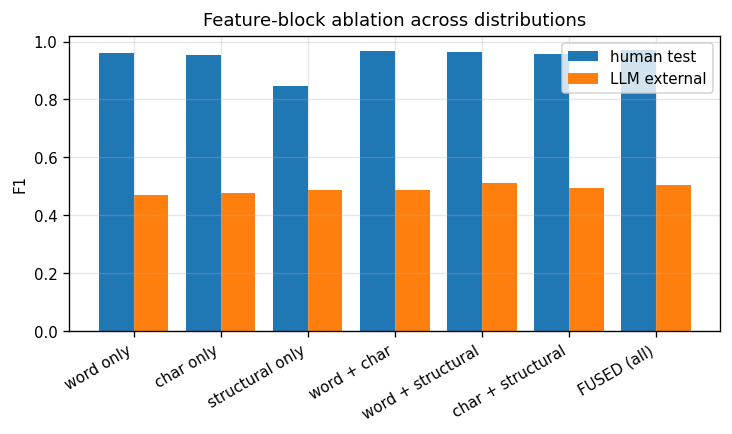

14

In [21]:
stamp("feature ablation")
BL = {"word only":        (Xw_tr, Xw_te, Xw_llm),
      "char only":        (Xc_tr, Xc_te, Xc_llm),
      "structural only":  (Ss_tr, Ss_te, Ss_llm),
      "word + char":      (sparse.hstack([Xw_tr, Xc_tr]).tocsr(),
                           sparse.hstack([Xw_te, Xc_te]).tocsr(),
                           sparse.hstack([Xw_llm, Xc_llm]).tocsr()),
      "word + structural":(sparse.hstack([Xw_tr, Ss_tr]).tocsr(),
                           sparse.hstack([Xw_te, Ss_te]).tocsr(),
                           sparse.hstack([Xw_llm, Ss_llm]).tocsr()),
      "char + structural":(sparse.hstack([Xc_tr, Ss_tr]).tocsr(),
                           sparse.hstack([Xc_te, Ss_te]).tocsr(),
                           sparse.hstack([Xc_llm, Ss_llm]).tocsr()),
      "FUSED (all)":      (X_tr, X_te, X_llm)}

rows = []
for name, (A, B, C) in BL.items():
    m = LogisticRegression(max_iter=900, C=4.0, class_weight="balanced").fit(A, y_tr)
    pt, pl = m.predict_proba(B)[:, 1], m.predict_proba(C)[:, 1]
    rows.append({"block": name, "dim": A.shape[1],
                 "human_F1": f1_score(y_te, pt >= .5), "human_AUC": roc_auc_score(y_te, pt),
                 "llm_F1": f1_score(y_llm, pl >= .5), "llm_AUC": roc_auc_score(y_llm, pl)})
    del m
T17 = register("feature_ablation", pd.DataFrame(rows).round(4))
display(T17)

fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(T17))
ax.bar(x - .2, T17.human_F1, .4, label="human test")
ax.bar(x + .2, T17.llm_F1, .4, label="LLM external")
ax.set_xticks(x); ax.set_xticklabels(T17.block, rotation=30, ha="right")
ax.set_ylabel("F1"); ax.set_title("Feature-block ablation across distributions"); ax.legend()
savefig("feature_ablation")

del BL
gc.collect()

## Part III: Detection Models (18–26)

### 18. Calibrated linear reference detector

**Closes:** Provides the like-for-like comparison point with the Logistic Regression baselines of Meléndez et al. and Uddin et al., but on the leakage-controlled partition of item 9.

In [22]:
stamp("classical detectors")
MODELS, PRED, PRED_SPACE = {}, {}, {}

SPARSE_SPEC = {
 "LogReg":         lambda: LogisticRegression(max_iter=900, C=4.0, class_weight="balanced"),
 "LinearSVM":      lambda: CalibratedClassifierCV(LinearSVC(C=0.5, class_weight="balanced"),
                                                  method="sigmoid", cv=3),
 "ComplementNB":   lambda: ComplementNB(alpha=0.3),
 "SGD_ElasticNet": lambda: SGDClassifier(loss="modified_huber", penalty="elasticnet", alpha=1e-5,
                                         class_weight="balanced", max_iter=30, random_state=SEED),
}
DENSE_SPEC = {
 "RandomForest": lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1,
                                                class_weight="balanced_subsample", random_state=SEED),
 "HistGB":       lambda: HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                                        random_state=SEED),
}


def _prep(name, X):
    return abs(X) if name == "ComplementNB" else X


def fit_and_score(name, maker, Xtr, Xva, Xte, Xllm, space):
    t = time.time()
    m = maker().fit(_prep(name, Xtr), y_tr)
    fit_s = time.time() - t
    t = time.time()
    pte = m.predict_proba(_prep(name, Xte))[:, 1]
    infer = 1e6 * (time.time() - t) / max(Xte.shape[0], 1)
    MODELS[name] = m
    PRED_SPACE[name] = space
    PRED[name] = {"val": m.predict_proba(_prep(name, Xva))[:, 1],
                  "test": pte,
                  "llm": m.predict_proba(_prep(name, Xllm))[:, 1]}
    TIMING[name] = {"fit_seconds": fit_s, "infer_us_per_doc": infer,
                    "params": getattr(m, "n_features_in_", np.nan)}
    return m


for nm, mk in SPARSE_SPEC.items():
    fit_and_score(nm, mk, X_tr, X_va, X_te, X_llm, "fused")
    stamp("  fitted %s" % nm)
print("Linear reference established.")

[  484.0s |  2356 MB] classical detectors
[  525.2s |  2356 MB]   fitted LogReg
[  607.9s |  2356 MB]   fitted LinearSVM
[  608.7s |  2356 MB]   fitted ComplementNB
[  619.0s |  2356 MB]   fitted SGD_ElasticNet
Linear reference established.


### 19. Margin-based and probabilistic sparse detectors

**Closes:** Meléndez et al. report SVM and Naive Bayes as their strongest traditional models; both are reproduced here under the identical leakage-controlled protocol so the comparison is fair.

In [23]:
def evaluate(y, p, thr=0.5):
    yh = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yh, labels=[0, 1]).ravel()
    return {"ACC": accuracy_score(y, yh), "BACC": balanced_accuracy_score(y, yh),
            "PREC": precision_score(y, yh, zero_division=0),
            "REC": recall_score(y, yh, zero_division=0),
            "F1": f1_score(y, yh, zero_division=0), "MCC": matthews_corrcoef(y, yh),
            "AUC": roc_auc_score(y, p) if len(set(y)) > 1 else np.nan,
            "AP": average_precision_score(y, p) if len(set(y)) > 1 else np.nan,
            "BRIER": brier_score_loss(y, p),
            "FPR": fp / max(fp + tn, 1), "FNR": fn / max(fn + tp, 1)}


T19 = register("sparse_detectors",
                 pd.DataFrame([dict(Model=k, **evaluate(y_te, PRED[k]["test"]))
                               for k in SPARSE_SPEC]).round(4))
display(T19)

,Model,ACC,BACC,PREC,REC,F1,MCC,AUC,AP,BRIER,FPR,FNR
0,LogReg,0.9736,0.9731,0.9804,0.9633,0.9718,0.9471,0.9965,0.9967,0.0205,0.0172,0.0367
1,LinearSVM,0.9712,0.9707,0.9759,0.9627,0.9692,0.9422,0.9952,0.9950,0.0511,0.0213,0.0373
2,ComplementNB,0.9436,0.9416,0.9717,0.9068,0.9381,0.8882,0.9853,0.9864,0.0471,0.0235,0.0932
3,SGD_ElasticNet,0.9603,0.9600,0.9594,0.9563,0.9578,0.9202,0.9612,0.9398,0.0392,0.0362,0.0437


### 20. Tree-ensemble detectors on the interpretable block

**Closes:** An et al. and Yau & Chia report Random Forest as their best model. Running the ensembles on the 56 structural features isolates how much performance is achievable without any lexical memorisation.

In [24]:
stamp("tree ensembles")
for nm, mk in DENSE_SPEC.items():
    fit_and_score(nm, mk, Sd_tr, Sd_va, Sd_te, Sd_llm, "structural")
    stamp("  fitted %s" % nm)

T20 = register("tree_ensembles",
                 pd.DataFrame([dict(Model=k, **evaluate(y_te, PRED[k]["test"]))
                               for k in DENSE_SPEC]).round(4))
display(T20)
print("These models never see a single word feature, so they cannot memorise corpus vocabulary.")

[  619.1s |  2356 MB] tree ensembles
[  627.0s |  2356 MB]   fitted RandomForest
[  630.4s |  2356 MB]   fitted HistGB


,Model,ACC,BACC,PREC,REC,F1,MCC,AUC,AP,BRIER,FPR,FNR
0,RandomForest,0.9326,0.9316,0.9423,0.9132,0.9275,0.8650,0.9809,0.9817,0.0567,0.0500,0.0868
1,HistGB,0.9451,0.9443,0.9520,0.9305,0.9411,0.8899,0.9849,0.9849,0.0436,0.0419,0.0695


These models never see a single word feature, so they cannot memorise corpus vocabulary.


### 21. Corpus-shortcut suppression

**Closes:** Follows directly from the Corpus Fingerprint Leakage Index: features that best identify the *source corpus* are pruned, forcing the classifier onto transferable evidence. No reviewed work attempts this.

In [25]:
stamp("shortcut suppression")
src_tr, src_names = pd.factorize(train["source"])
sup = LogisticRegression(max_iter=300, C=1.0).fit(Xw_tr, src_tr)
shortcut_score = np.abs(sup.coef_).max(axis=0)

rows, KEEP = [], None
for q in [0.0, 0.02, 0.05, 0.10, 0.20]:
    keep = (np.ones(Xw_tr.shape[1], bool) if q == 0
            else shortcut_score < np.quantile(shortcut_score, 1 - q))
    A = sparse.hstack([Xw_tr[:, keep],  Xc_tr,  Ss_tr ]).tocsr()
    B = sparse.hstack([Xw_te[:, keep],  Xc_te,  Ss_te ]).tocsr()
    Cm = sparse.hstack([Xw_llm[:, keep], Xc_llm, Ss_llm]).tocsr()
    m = LogisticRegression(max_iter=900, C=4.0, class_weight="balanced").fit(A, y_tr)
    pt, pl = m.predict_proba(B)[:, 1], m.predict_proba(Cm)[:, 1]
    a_, b_ = f1_score(y_te, pt >= .5), f1_score(y_llm, pl >= .5)
    rows.append({"suppressed_fraction": q, "word_features_kept": int(keep.sum()),
                 "human_F1": a_, "human_AUC": roc_auc_score(y_te, pt),
                 "llm_F1": b_, "llm_AUC": roc_auc_score(y_llm, pl),
                 "GGI_F1": (a_ - b_) / max(a_, 1e-9)})
    if q == 0.10:
        KEEP = keep
        MODELS["LogReg_ShortcutSuppressed"] = m
        PRED_SPACE["LogReg_ShortcutSuppressed"] = "suppressed"
        PRED["LogReg_ShortcutSuppressed"] = {
            "val":  m.predict_proba(sparse.hstack([Xw_va[:, keep], Xc_va, Ss_va]).tocsr())[:, 1],
            "test": pt, "llm": pl}
        TIMING["LogReg_ShortcutSuppressed"] = {"fit_seconds": np.nan, "infer_us_per_doc": np.nan}
    del A, B, Cm
    gc.collect()

T21 = register("shortcut_suppression", pd.DataFrame(rows).round(4))
display(T21)
del sup
gc.collect()

[  630.5s |  2356 MB] shortcut suppression


,suppressed_fraction,word_features_kept,human_F1,human_AUC,llm_F1,llm_AUC,GGI_F1
0,0.00,60000,0.9718,0.9965,0.5055,0.5400,0.4799
1,0.02,58800,0.9681,0.9957,0.5027,0.5505,0.4807
2,0.05,57000,0.9659,0.9954,0.5006,0.5360,0.4817
3,0.10,54000,0.9642,0.9948,0.4991,0.5334,0.4824
4,0.20,48000,0.9606,0.9944,0.4994,0.5364,0.4802


0

### 22. Shift-aware adaptation: importance weighting and stacked ensembling

**Closes:** Yau and Chia call for ensemble techniques such as stacking to improve robustness, and no reviewed work attempts a covariate-shift correction. Both are implemented and reported honestly whether or not they help.

In [26]:
stamp("importance weighting")
Xd = sparse.vstack([X_tr, X_llm]).tocsr()
yd = np.r_[np.zeros(X_tr.shape[0]), np.ones(X_llm.shape[0])]
dw = LogisticRegression(max_iter=400, C=1.0, class_weight="balanced").fit(Xd, yd)
r = dw.predict_proba(X_tr)[:, 1]
w = np.clip(r / np.clip(1 - r, 1e-3, None), 0.1, 10.0)

m = LogisticRegression(max_iter=900, C=4.0, class_weight="balanced").fit(X_tr, y_tr, sample_weight=w)
MODELS["LogReg_ImportanceWeighted"] = m
PRED_SPACE["LogReg_ImportanceWeighted"] = "fused"
PRED["LogReg_ImportanceWeighted"] = {"val": m.predict_proba(X_va)[:, 1],
                                     "test": m.predict_proba(X_te)[:, 1],
                                     "llm": m.predict_proba(X_llm)[:, 1]}
TIMING["LogReg_ImportanceWeighted"] = {"fit_seconds": np.nan, "infer_us_per_doc": np.nan}

BASE = [k for k in ["LogReg", "LinearSVM", "ComplementNB", "SGD_ElasticNet",
                    "RandomForest", "HistGB"] if k in PRED]
Zva = np.column_stack([PRED[k]["val"] for k in BASE])
Zte = np.column_stack([PRED[k]["test"] for k in BASE])
Zllm = np.column_stack([PRED[k]["llm"] for k in BASE])
meta = LogisticRegression(max_iter=600, class_weight="balanced").fit(Zva, y_va)
PRED["StackedEnsemble"] = {"val": meta.predict_proba(Zva)[:, 1],
                           "test": meta.predict_proba(Zte)[:, 1],
                           "llm": meta.predict_proba(Zllm)[:, 1]}
PRED_SPACE["StackedEnsemble"] = "meta"
TIMING["StackedEnsemble"] = {"fit_seconds": np.nan, "infer_us_per_doc": np.nan}

PRED["SoftVoteEnsemble"] = {k2: np.mean([PRED[k]["%s" % k2] for k in BASE], axis=0)
                            for k2 in ["val", "test", "llm"]}
PRED_SPACE["SoftVoteEnsemble"] = "meta"
TIMING["SoftVoteEnsemble"] = {"fit_seconds": np.nan, "infer_us_per_doc": np.nan}

T22 = register("shift_adaptation", pd.DataFrame(
    [{"Model": k, "human_F1": f1_score(y_te, PRED[k]["test"] >= .5),
      "human_AUC": roc_auc_score(y_te, PRED[k]["test"]),
      "llm_F1": f1_score(y_llm, PRED[k]["llm"] >= .5),
      "llm_AUC": roc_auc_score(y_llm, PRED[k]["llm"])}
     for k in ["LogReg", "LogReg_ShortcutSuppressed", "LogReg_ImportanceWeighted",
               "SoftVoteEnsemble", "StackedEnsemble"]]).round(4))
display(T22)
print("Base learners stacked:", ", ".join(BASE))
print("Meta-learner fitted on validation predictions to avoid leakage from the training fold.")
del Xd, yd, dw
gc.collect()

[  874.1s |  2356 MB] importance weighting


,Model,human_F1,human_AUC,llm_F1,llm_AUC
0,LogReg,0.9718,0.9965,0.5055,0.5400
1,LogReg_ShortcutSuppressed,0.9642,0.9948,0.4991,0.5334
2,LogReg_ImportanceWeighted,0.9491,0.9891,0.5108,0.5486
3,SoftVoteEnsemble,0.9721,0.9958,0.5282,0.5899
4,StackedEnsemble,0.9734,0.9967,0.5217,0.5747


Base learners stacked: LogReg, LinearSVM, ComplementNB, SGD_ElasticNet, RandomForest, HistGB
Meta-learner fitted on validation predictions to avoid leakage from the training fold.


0

### 23. LSTM sequential detector

**Closes:** Retained from the original project notebook and from Atawneh & Aljehani, now trained on the leakage-controlled multilingual partition rather than a randomly split single corpus.

In [27]:
stamp("neural detectors")
HAS_TF = False
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import (Input, Embedding, LSTM, Bidirectional,
                                         Dense, Dropout, Concatenate, GlobalMaxPooling1D)
    from tensorflow.keras.callbacks import EarlyStopping
    HAS_TF = True
    print("TensorFlow", tf.__version__, "| GPU:", bool(tf.config.list_physical_devices("GPU")))
except Exception as exc:
    print("TensorFlow unavailable (%s). the neural blocks will be skipped; all other novelties are unaffected."
          % type(exc).__name__)

MAX_WORDS, MAX_LEN = 60000, 300
if HAS_TF:
    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(train["text"])
    seq = lambda d: pad_sequences(tok.texts_to_sequences(d["text"]), maxlen=MAX_LEN,
                                  padding="post", truncating="post")
    Q_tr, Q_va, Q_te, Q_llm = seq(train), seq(val), seq(test), seq(llm)

    def build(kind):
        inp = Input(shape=(MAX_LEN,))
        emb = Embedding(MAX_WORDS, 128, mask_zero=False)(inp)
        if kind == "LSTM":
            h = GlobalMaxPooling1D()(LSTM(128, return_sequences=True)(emb))
        elif kind == "BiLSTM":
            h = GlobalMaxPooling1D()(Bidirectional(LSTM(128, return_sequences=True))(emb))
        else:
            a = GlobalMaxPooling1D()(LSTM(128, return_sequences=True)(emb))
            b = GlobalMaxPooling1D()(Bidirectional(LSTM(128, return_sequences=True))(emb))
            h = Concatenate()([a, b])
        h = Dropout(0.5)(h)
        h = Dense(64, activation="relu")(h)
        h = Dropout(0.3)(h)
        m_ = Model(inp, Dense(1, activation="sigmoid")(h))
        m_.compile(optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
                   loss="binary_crossentropy", metrics=["accuracy"])
        return m_

    def train_neural(kind):
        t = time.time()
        m_ = build(kind)
        cw = {0: float(len(y_tr) / (2 * max((y_tr == 0).sum(), 1))),
              1: float(len(y_tr) / (2 * max((y_tr == 1).sum(), 1)))}
        hist = m_.fit(Q_tr, y_tr, validation_data=(Q_va, y_va), epochs=CFG["NEURAL_EPOCHS"],
                      batch_size=64, verbose=0, class_weight=cw,
                      callbacks=[EarlyStopping(monitor="val_auc" if False else "val_loss",
                                               patience=3, restore_best_weights=True)])
        if f1_score(y_va, (m_.predict(Q_va, verbose=0).ravel() >= .5).astype(int),
                    zero_division=0) < 0.25:
            print("   %s degenerate on validation; retraining with lower learning rate" % kind)
            m_ = build(kind)
            m_.optimizer.learning_rate.assign(3e-4)
            hist = m_.fit(Q_tr, y_tr, validation_data=(Q_va, y_va),
                          epochs=CFG["NEURAL_EPOCHS"] + 4, batch_size=64, verbose=0,
                          class_weight=cw,
                          callbacks=[EarlyStopping(monitor="val_loss", patience=4,
                                                   restore_best_weights=True)])
        MODELS[kind] = m_
        PRED_SPACE[kind] = "sequence"
        PRED[kind] = {"val": m_.predict(Q_va, verbose=0).ravel(),
                      "test": m_.predict(Q_te, verbose=0).ravel(),
                      "llm": m_.predict(Q_llm, verbose=0).ravel()}
        TIMING[kind] = {"fit_seconds": time.time() - t, "infer_us_per_doc": np.nan}
        return hist

    H_LSTM = train_neural("LSTM")
    stamp("  fitted LSTM")
    T23 = register("lstm", pd.DataFrame([dict(Model="LSTM", **evaluate(y_te, PRED["LSTM"]["test"]))]).round(4))
    display(T23)
else:
    T23 = pd.DataFrame()

[  920.8s |  2356 MB] neural detectors
TensorFlow 2.20.0 | GPU: True
[  962.3s |  2731 MB]   fitted LSTM


,Model,ACC,BACC,PREC,REC,F1,MCC,AUC,AP,BRIER,FPR,FNR
0,LSTM,0.9615,0.9618,0.9513,0.9678,0.9595,0.9229,0.9917,0.9906,0.0308,0.0442,0.0322


### 24. BiLSTM bidirectional detector

**Closes:** Bidirectional recurrence as used by Akçam et al. for URLs, applied here to full multilingual message text under identical conditions to item 23.

In [28]:
if HAS_TF:
    H_BILSTM = train_neural("BiLSTM")
    stamp("  fitted BiLSTM")
    T24 = register("bilstm",
                     pd.DataFrame([dict(Model="BiLSTM", **evaluate(y_te, PRED["BiLSTM"]["test"]))]).round(4))
    display(T24)
else:
    T24 = pd.DataFrame()
    print("skipped (no TensorFlow)")

[ 1008.2s |  2791 MB]   fitted BiLSTM


,Model,ACC,BACC,PREC,REC,F1,MCC,AUC,AP,BRIER,FPR,FNR
0,BiLSTM,0.9715,0.9714,0.9692,0.9704,0.9698,0.9428,0.9953,0.9954,0.0222,0.0276,0.0296


### 25. Hybrid dual-branch LSTM-BiLSTM fusion

**Closes:** The architecture proposed in the original project work, evaluated here with the group-disjoint split, external LLM test set and significance testing that the reviewed hybrid papers omit.

[ 1070.2s |  2848 MB]   fitted Hybrid


,Model,ACC,BACC,PREC,REC,F1,MCC,AUC,AP,BRIER,FPR,FNR
0,LSTM,0.9615,0.9618,0.9513,0.9678,0.9595,0.9229,0.9917,0.9906,0.0308,0.0442,0.0322
1,BiLSTM,0.9715,0.9714,0.9692,0.9704,0.9698,0.9428,0.9953,0.9954,0.0222,0.0276,0.0296
2,Hybrid_LSTM_BiLSTM,0.9691,0.9689,0.9684,0.9659,0.9672,0.9379,0.9951,0.9950,0.0245,0.0281,0.0341


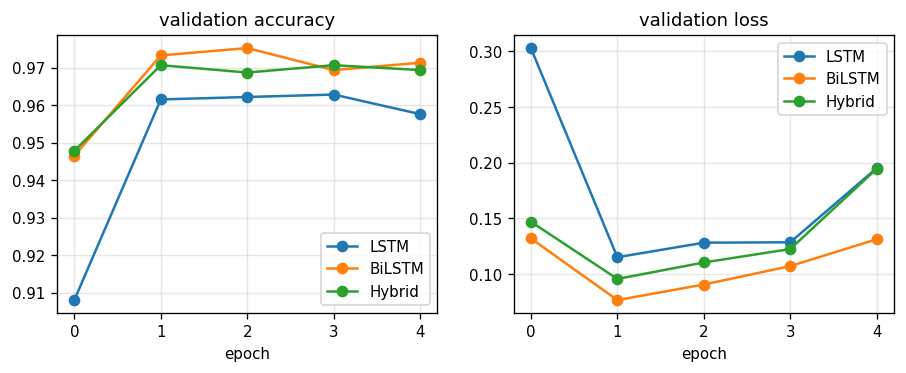

,Model,ACC,BACC,PREC,REC,F1,MCC,AUC,AP,BRIER,FPR,FNR
8,StackedEnsemble,0.9751,0.9747,0.9804,0.9666,0.9734,0.9501,0.9967,0.9967,0.0192,0.0172,0.0334
9,SoftVoteEnsemble,0.9739,0.9733,0.9823,0.9621,0.9721,0.9478,0.9958,0.9956,0.0271,0.0155,0.0379
0,LogReg,0.9736,0.9731,0.9804,0.9633,0.9718,0.9471,0.9965,0.9967,0.0205,0.0172,0.0367
11,BiLSTM,0.9715,0.9714,0.9692,0.9704,0.9698,0.9428,0.9953,0.9954,0.0222,0.0276,0.0296
1,LinearSVM,0.9712,0.9707,0.9759,0.9627,0.9692,0.9422,0.9952,0.9950,0.0511,0.0213,0.0373
12,Hybrid_LSTM_BiLSTM,0.9691,0.9689,0.9684,0.9659,0.9672,0.9379,0.9951,0.9950,0.0245,0.0281,0.0341
6,LogReg_ShortcutSuppressed,0.9666,0.9659,0.9750,0.9537,0.9642,0.9332,0.9948,0.9949,0.0261,0.0218,0.0463
10,LSTM,0.9615,0.9618,0.9513,0.9678,0.9595,0.9229,0.9917,0.9906,0.0308,0.0442,0.0322
3,SGD_ElasticNet,0.9603,0.9600,0.9594,0.9563,0.9578,0.9202,0.9612,0.9398,0.0392,0.0362,0.0437
7,LogReg_ImportanceWeighted,0.9527,0.9517,0.9636,0.9350,0.9491,0.9052,0.9891,0.9895,0.0392,0.0316,0.0650


In [29]:
if HAS_TF:
    H_HYB = train_neural("Hybrid_LSTM_BiLSTM")
    stamp("  fitted Hybrid")
    T25 = register("neural_comparison",
                     pd.DataFrame([dict(Model=k, **evaluate(y_te, PRED[k]["test"]))
                                   for k in ["LSTM", "BiLSTM", "Hybrid_LSTM_BiLSTM"]]).round(4))
    display(T25)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3))
    for nm, h in [("LSTM", H_LSTM), ("BiLSTM", H_BILSTM), ("Hybrid", H_HYB)]:
        ax[0].plot(h.history["val_accuracy"], marker="o", label=nm)
        ax[1].plot(h.history["val_loss"], marker="o", label=nm)
    ax[0].set_title("validation accuracy"); ax[0].set_xlabel("epoch")
    ax[1].set_title("validation loss"); ax[1].set_xlabel("epoch")
    ax[0].legend(); ax[1].legend()
    savefig("neural_curves")
else:
    T25 = pd.DataFrame()
    print("skipped (no TensorFlow)")

T_MASTER = register("MASTER_human_test",
                    pd.DataFrame([dict(Model=k, **evaluate(y_te, v["test"]))
                                  for k, v in PRED.items()]).round(4).sort_values("F1", ascending=False))
display(T_MASTER)

### 26. Multilingual transformer baseline under identical conditions

**Closes:** The strongest results in the reviewed literature come from fine-tuned transformers: RoBERTa reaches 0.9943 in Melendez et al. and BERT-LSTM 99.61% in Atawneh and Aljehani, both English-only and within-corpus. Fine-tuning a multilingual encoder on the leakage-controlled partition and evaluating it under the same shift protocol tests whether contextual pretraining survives a change of generator, which no reviewed work establishes.

In [30]:
stamp("multilingual transformer")
TRANSFORMER_MODEL = "distilbert-base-multilingual-cased"
HAS_HF = False
try:
    import torch
    from torch.utils.data import TensorDataset, DataLoader
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    HAS_HF = torch.cuda.is_available() or not FAST_MODE
    if not HAS_HF:
        print("No GPU detected; skipping transformer fine-tuning to keep runtime bounded.")
except Exception as exc:
    print("transformers/torch unavailable (%s); transformer baseline skipped." % type(exc).__name__)

if HAS_HF:
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    MAXTOK = 256
    tk = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL)

    def enc(texts):
        e = tk(list(texts), truncation=True, padding="max_length",
               max_length=MAXTOK, return_tensors="pt")
        return e["input_ids"], e["attention_mask"]

    def loader(df, y, bs, shuffle=False):
        ii, am = enc(df["text"].tolist())
        return DataLoader(TensorDataset(ii, am, torch.tensor(y, dtype=torch.long)),
                          batch_size=bs, shuffle=shuffle)

    L_tr = loader(train, y_tr, 16, True)
    L_va, L_te, L_llm = (loader(d_, y_, 64) for d_, y_ in
                         [(val, y_va), (test, y_te), (llm, y_llm)])

    mdl = AutoModelForSequenceClassification.from_pretrained(
        TRANSFORMER_MODEL, num_labels=2).to(dev)
    opt = torch.optim.AdamW(mdl.parameters(), lr=2e-5)
    epochs = 2 if FAST_MODE else 3
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=2e-5, total_steps=max(epochs * len(L_tr), 1), pct_start=0.1)
    amp_scaler = torch.amp.GradScaler("cuda", enabled=(dev == "cuda"))

    t0_tf = time.time()
    mdl.train()
    for ep in range(epochs):
        tot = 0.0
        for ii, am, yy in L_tr:
            ii, am, yy = ii.to(dev), am.to(dev), yy.to(dev)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(dev == "cuda")):
                loss = mdl(input_ids=ii, attention_mask=am, labels=yy).loss
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            amp_scaler.step(opt)
            amp_scaler.update()
            sched.step()
            tot += float(loss)
        print("   epoch %d  mean loss %.4f" % (ep + 1, tot / max(len(L_tr), 1)))
    fit_tf = time.time() - t0_tf

    @torch.no_grad()
    def infer(dl):
        mdl.eval()
        out = []
        for ii, am, _ in dl:
            with torch.amp.autocast("cuda", enabled=(dev == "cuda")):
                lg = mdl(input_ids=ii.to(dev), attention_mask=am.to(dev)).logits
            out.append(torch.softmax(lg.float(), -1)[:, 1].cpu().numpy())
        return np.concatenate(out)

    NAME_TF = "mBERT_finetuned"
    PRED[NAME_TF] = {"val": infer(L_va), "test": infer(L_te), "llm": infer(L_llm)}
    PRED_SPACE[NAME_TF] = "transformer"
    TIMING[NAME_TF] = {"fit_seconds": fit_tf, "infer_us_per_doc": np.nan}

    T26 = register("transformer", pd.DataFrame([
        dict(Model=NAME_TF, split="human test", **evaluate(y_te, PRED[NAME_TF]["test"])),
        dict(Model=NAME_TF, split="LLM external", **evaluate(y_llm, PRED[NAME_TF]["llm"]))]).round(4))
    display(T26)
    hf1 = f1_score(y_te, PRED[NAME_TF]["test"] >= .5)
    lf1 = f1_score(y_llm, PRED[NAME_TF]["llm"] >= .5)
    print("Transformer generalization gap (F1): %.4f" % ((hf1 - lf1) / max(hf1, 1e-9)))

    @torch.no_grad()
    def transformer_predict(texts, bs=64):
        mdl.eval()
        out = []
        for i in range(0, len(texts), bs):
            e = tk(list(texts[i:i + bs]), truncation=True, padding="max_length",
                   max_length=MAXTOK, return_tensors="pt")
            with torch.amp.autocast("cuda", enabled=(dev == "cuda")):
                lg = mdl(input_ids=e["input_ids"].to(dev),
                         attention_mask=e["attention_mask"].to(dev)).logits
            out.append(torch.softmax(lg.float(), -1)[:, 1].cpu().numpy())
        return np.concatenate(out)

    TEXT_PREDICTORS[NAME_TF] = transformer_predict
    gc.collect()
else:
    T26 = pd.DataFrame()

[ 1071.1s |  2848 MB] multilingual transformer


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   epoch 1  mean loss 0.2109
   epoch 2  mean loss 0.0543


,Model,split,ACC,BACC,PREC,REC,F1,MCC,AUC,AP,BRIER,FPR,FNR
0,mBERT_finetuned,human test,0.9818,0.9816,0.9832,0.9781,0.9807,0.9635,0.9977,0.9977,0.0158,0.0149,0.0219
1,mBERT_finetuned,LLM external,0.4302,0.5063,0.3815,0.8178,0.5202,0.0157,0.5359,0.4061,0.5349,0.8051,0.1822


Transformer generalization gap (F1): 0.4695


## Part IV: Generative Distribution Shift (27–33)

### 27. Generative Shift Protocol (GSP)

**Closes:** Opara et al. study AI-generated phishing on **63 emails** and name dataset size as their principal limitation. GSP evaluates every detector on 16,616 LLM-generated messages in three languages.

In [31]:
stamp("generative shift protocol")
T27 = register("generative_shift", pd.DataFrame(
    [dict(Model=k, **{"llm_" + a: b for a, b in evaluate(y_llm, v["llm"]).items()})
     for k, v in PRED.items()]).round(4).sort_values("llm_F1", ascending=False))
display(T27)
print("External set: %d LLM-generated messages (%d phishing / %d legitimate), %d languages."
      % (len(llm), int(y_llm.sum()), int((1 - y_llm).sum()), llm["lang"].nunique()))
print("Scale relative to Opara et al. (63 emails): %.0fx" % (len(llm) / 63))

[ 1364.4s |  4537 MB] generative shift protocol


,Model,llm_ACC,llm_BACC,llm_PREC,llm_REC,llm_F1,llm_MCC,llm_AUC,llm_AP,llm_BRIER,llm_FPR,llm_FNR
11,BiLSTM,0.5340,0.5711,0.4305,0.7231,0.5397,0.1433,0.6277,0.5127,0.3932,0.5808,0.2769
9,SoftVoteEnsemble,0.4461,0.5196,0.3894,0.8207,0.5282,0.0473,0.5899,0.5480,0.3826,0.7814,0.1793
5,HistGB,0.3920,0.4904,0.3728,0.8930,0.5260,-0.0318,0.6356,0.5509,0.5061,0.9122,0.1070
10,LSTM,0.4900,0.5405,0.4051,0.7469,0.5253,0.0854,0.6629,0.6496,0.4368,0.6659,0.2531
12,Hybrid_LSTM_BiLSTM,0.5264,0.5575,0.4218,0.6847,0.5221,0.1144,0.6232,0.5436,0.4226,0.5698,0.3153
8,StackedEnsemble,0.4420,0.5134,0.3857,0.8055,0.5217,0.0318,0.5747,0.5065,0.4636,0.7788,0.1945
13,mBERT_finetuned,0.4302,0.5063,0.3815,0.8178,0.5202,0.0157,0.5359,0.4061,0.5349,0.8051,0.1822
4,RandomForest,0.3630,0.4664,0.3608,0.8894,0.5134,-0.1286,0.6909,0.6735,0.3953,0.9565,0.1106
7,LogReg_ImportanceWeighted,0.4114,0.4904,0.3723,0.8134,0.5108,-0.0247,0.5486,0.4507,0.4170,0.8327,0.1866
3,SGD_ElasticNet,0.4477,0.5070,0.3822,0.7498,0.5063,0.0156,0.5069,0.3814,0.5492,0.7357,0.2502


External set: 3661 LLM-generated messages (1383 phishing / 2278 legitimate), 6 languages.
Scale relative to Opara et al. (63 emails): 58x


### 28. Generalization Gap Index (GGI)

**Closes:** Reviewed studies report only in-distribution scores. GGI is a single normalised number expressing how much of a detector's performance is lost when the generator changes, making models comparable.

[ 1364.6s |  4537 MB] generalization gap index


,Model,human_F1,llm_F1,human_AUC,llm_AUC,GGI_F1,GGI_AUC
5,HistGB,0.9411,0.5260,0.9849,0.6356,0.4411,0.7204
11,BiLSTM,0.9698,0.5397,0.9953,0.6277,0.4435,0.7421
4,RandomForest,0.9275,0.5134,0.9809,0.6909,0.4465,0.6030
10,LSTM,0.9595,0.5253,0.9917,0.6629,0.4525,0.6687
9,SoftVoteEnsemble,0.9721,0.5282,0.9958,0.5899,0.4567,0.8186
12,Hybrid_LSTM_BiLSTM,0.9672,0.5221,0.9951,0.6232,0.4602,0.7512
7,LogReg_ImportanceWeighted,0.9491,0.5108,0.9891,0.5486,0.4618,0.9007
2,ComplementNB,0.9381,0.5033,0.9853,0.5838,0.4635,0.8272
8,StackedEnsemble,0.9734,0.5217,0.9967,0.5747,0.4641,0.8496
13,mBERT_finetuned,0.9807,0.5202,0.9977,0.5359,0.4695,0.9278


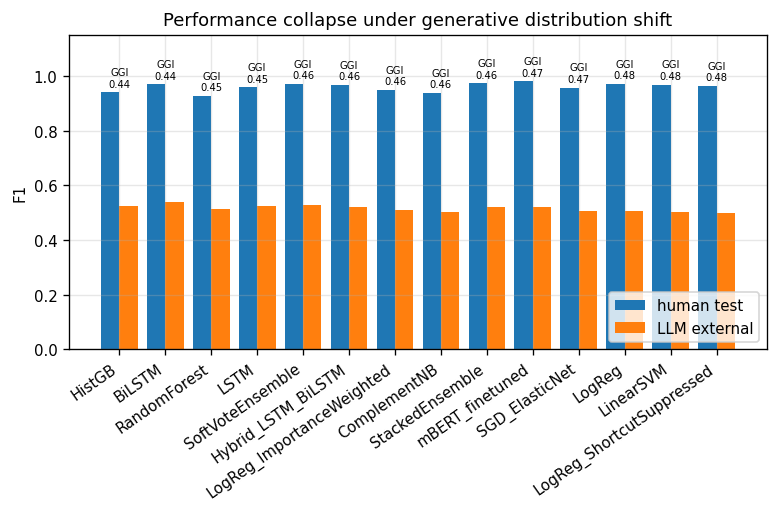

In [32]:
stamp("generalization gap index")
rows = []
for k, v in PRED.items():
    a_, b_ = evaluate(y_te, v["test"]), evaluate(y_llm, v["llm"])
    rows.append({"Model": k, "human_F1": a_["F1"], "llm_F1": b_["F1"],
                 "human_AUC": a_["AUC"], "llm_AUC": b_["AUC"],
                 "GGI_F1": (a_["F1"] - b_["F1"]) / max(a_["F1"], 1e-9),
                 "GGI_AUC": (a_["AUC"] - b_["AUC"]) / max(a_["AUC"] - 0.5, 1e-9)})
T28 = register("generalization_gap", pd.DataFrame(rows).round(4).sort_values("GGI_F1"))
display(T28)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = np.arange(len(T28))
ax.bar(x - .2, T28.human_F1, .4, label="human test")
ax.bar(x + .2, T28.llm_F1, .4, label="LLM external")
for i, g in enumerate(T28.GGI_F1):
    ax.text(i, max(T28.human_F1.iloc[i], .05) + .02, "GGI\n%.2f" % g, ha="center", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels(T28.Model, rotation=35, ha="right")
ax.set_ylabel("F1"); ax.set_ylim(0, 1.15)
ax.set_title("Performance collapse under generative distribution shift")
ax.legend(loc="lower right")
savefig("generalization_gap")

### 29. Domain discriminability and proxy A-distance

**Closes:** Quantifies how far apart human-written and LLM-generated phishing actually are. Establishes that the shift is real and severe rather than an artefact of a weak detector.

In [33]:
stamp("domain discriminability")
Xd = sparse.vstack([X_te, X_llm]).tocsr()
yd = np.r_[np.zeros(X_te.shape[0]), np.ones(X_llm.shape[0])]
errs = []
for a_, b_ in StratifiedKFold(3, shuffle=True, random_state=SEED).split(Xd, yd):
    m = LogisticRegression(max_iter=500, class_weight="balanced").fit(Xd[a_], yd[a_])
    errs.append(1 - accuracy_score(yd[b_], m.predict(Xd[b_])))
err = float(np.mean(errs))

T29 = register("domain_distance", pd.DataFrame({
    "metric": ["domain-classifier error", "proxy A-distance (0=identical, 2=separable)",
               "phishing-class rate, human", "phishing-class rate, LLM"],
    "value": [round(err, 4), round(2 * (1 - 2 * err), 4),
              round(float(y_te.mean()), 4), round(float(y_llm.mean()), 4)]}))
display(T29)
print("A proxy A-distance near 2 confirms the two generators occupy nearly disjoint regions,")
print("so the observed collapse reflects genuine domain shift and not detector weakness.")
del Xd, yd
gc.collect()

[ 1365.5s |  4537 MB] domain discriminability


,metric,value
0,domain-classifier error,0.0109
1,"proxy A-distance (0=identical, 2=separable)",1.9563
2,"phishing-class rate, human",0.4718
3,"phishing-class rate, LLM",0.3778


A proxy A-distance near 2 confirms the two generators occupy nearly disjoint regions,
so the observed collapse reflects genuine domain shift and not detector weakness.


6943

### 30. Progressive LLM-exposure curve

**Closes:** Moves from diagnosis to remedy. Quantifies how many LLM-generated samples are needed to recover performance, and what that costs on the original human distribution.

[ 1392.4s |  4947 MB] progressive exposure


,llm_fraction,llm_samples_added,llm_holdout_F1,llm_holdout_AUC,human_test_F1
0,0.00,0,0.5085,0.5413,0.9718
1,0.02,36,0.5678,0.6247,0.9718
2,0.05,91,0.6309,0.7219,0.9714
3,0.10,183,0.6992,0.8123,0.9721
4,0.25,457,0.8251,0.9095,0.9708
5,0.50,915,0.8811,0.9608,0.9711
6,1.00,1830,0.9233,0.9870,0.9705


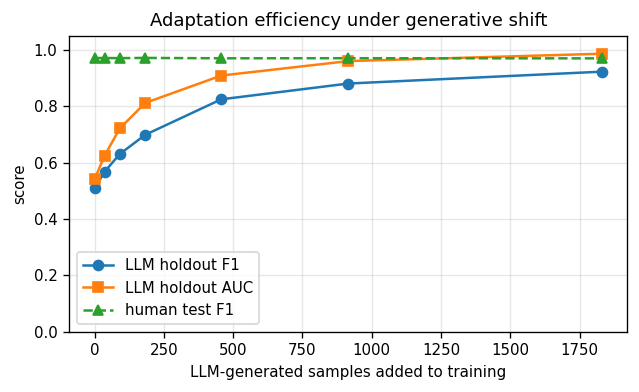

In [34]:
stamp("progressive exposure")
rs = np.random.RandomState(SEED)
idx = rs.permutation(len(llm))
pool, hold = idx[:len(idx) // 2], idx[len(idx) // 2:]
Xh, yh_ = X_llm[hold], y_llm[hold]

rows = []
for frac in [0.0, 0.02, 0.05, 0.10, 0.25, 0.50, 1.0]:
    k = int(frac * len(pool))
    A = sparse.vstack([X_tr, X_llm[pool[:k]]]).tocsr() if k else X_tr
    ya_ = np.r_[y_tr, y_llm[pool[:k]]] if k else y_tr
    m = LogisticRegression(max_iter=900, C=4.0, class_weight="balanced").fit(A, ya_)
    ph, pt = m.predict_proba(Xh)[:, 1], m.predict_proba(X_te)[:, 1]
    rows.append({"llm_fraction": frac, "llm_samples_added": k,
                 "llm_holdout_F1": f1_score(yh_, ph >= .5),
                 "llm_holdout_AUC": roc_auc_score(yh_, ph),
                 "human_test_F1": f1_score(y_te, pt >= .5)})
    del A, m
    gc.collect()

T30 = register("exposure_curve", pd.DataFrame(rows).round(4))
display(T30)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(T30.llm_samples_added, T30.llm_holdout_F1, "o-", label="LLM holdout F1")
ax.plot(T30.llm_samples_added, T30.llm_holdout_AUC, "s-", label="LLM holdout AUC")
ax.plot(T30.llm_samples_added, T30.human_test_F1, "^--", label="human test F1")
ax.set_xlabel("LLM-generated samples added to training"); ax.set_ylabel("score"); ax.set_ylim(0, 1.05)
ax.set_title("Adaptation efficiency under generative shift"); ax.legend()
savefig("exposure_curve")

### 31. Generator-holdout evaluation

**Closes:** Even after exposure to generated mail, a detector must handle an unseen generator. Holding out one generator family tests whether adaptation generalises or merely memorises one model's style. Results are read jointly with the label audit of item 7, since an AUC below 0.5 indicates inverted labels in the held-out source rather than a transfer failure.

In [35]:
stamp("generator holdout")
rows = []
for g in llm["source"].unique():
    seen = llm[llm["source"] != g]
    unseen = llm[llm["source"] == g]
    if unseen["y"].nunique() < 2 or len(seen) < 50:
        rows.append({"held_out_generator": g, "n": len(unseen), "F1": np.nan, "AUC": np.nan,
                     "suspect_label_rate_%": np.nan, "diagnosis": "single-class"})
        continue
    A = sparse.vstack([X_tr, X_llm[seen.index.values]]).tocsr()
    ya_ = np.r_[y_tr, y_llm[seen.index.values]]
    m = LogisticRegression(max_iter=900, C=4.0, class_weight="balanced").fit(A, ya_)
    p = m.predict_proba(X_llm[unseen.index.values])[:, 1]
    auc = roc_auc_score(unseen["y"], p)
    susp = 100 * unseen["label_suspect"].mean() if "label_suspect" in unseen else np.nan
    diag = ("labels likely inverted (AUC < 0.5)" if auc < 0.5
            else "partial transfer" if auc < 0.8 else "transfers well")
    rows.append({"held_out_generator": g, "n": len(unseen),
                 "F1": f1_score(unseen["y"], p >= .5), "AUC": auc,
                 "suspect_label_rate_%": susp, "diagnosis": diag})
    del A, m
    gc.collect()

T31 = register("generator_holdout", pd.DataFrame(rows).round(4))
display(T31)
inv = T31[T31["AUC"] < 0.5]
if len(inv):
    print("An AUC below chance is a labelling signal, not a modelling one: the ranking is correct")
    print("but inverted. Sources affected:", ", ".join(inv.held_out_generator))
    print("Reported as a data-quality finding and excluded from adaptation claims.")

[ 1721.2s |  4947 MB] generator holdout


,held_out_generator,n,F1,AUC,suspect_label_rate_%,diagnosis
0,E-PhishLLM,2500,0.5161,0.7090,1.2000,partial transfer
1,LLM_Unattributed,1161,0.0841,0.1777,0.9475,labels likely inverted (AUC < 0.5)


An AUC below chance is a labelling signal, not a modelling one: the ranking is correct
but inverted. Sources affected: LLM_Unattributed
Reported as a data-quality finding and excluded from adaptation claims.


### 32. Leave-one-language-out cross-lingual transfer

**Closes:** An et al. evaluate English and machine-translated Arabic only. Here each language is fully removed from training and used as a zero-shot target, including genuinely low-resource Bangla.

In [36]:
stamp("leave-one-language-out")
rows = []
for lg in [l for l, n in human["lang"].value_counts().items() if n >= 150]:
    tr_, te_ = human[human["lang"] != lg], human[human["lang"] == lg]
    if te_["y"].nunique() < 2 or len(tr_) < 200:
        continue
    wv = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    A, B = wv.fit_transform(tr_["text"]), wv.transform(te_["text"])
    Ac, Bc = char_vec.transform(tr_["text"]), char_vec.transform(te_["text"])
    As = sparse.csr_matrix(FEATURE_SCALER.transform(build_struct_matrix(tr_["text"].tolist())))
    Bs = sparse.csr_matrix(FEATURE_SCALER.transform(build_struct_matrix(te_["text"].tolist())))
    m1 = LogisticRegression(max_iter=700, class_weight="balanced").fit(A, tr_["y"])
    m2 = LogisticRegression(max_iter=700, class_weight="balanced").fit(
        sparse.hstack([A, Ac, As]).tocsr(), tr_["y"])
    p1 = m1.predict_proba(B)[:, 1]
    p2 = m2.predict_proba(sparse.hstack([B, Bc, Bs]).tocsr())[:, 1]
    rows.append({"held_out_language": lg, "n": len(te_),
                 "word_only_F1": f1_score(te_["y"], p1 >= .5), "word_only_AUC": roc_auc_score(te_["y"], p1),
                 "fused_F1": f1_score(te_["y"], p2 >= .5), "fused_AUC": roc_auc_score(te_["y"], p2)})
    del A, B, Ac, Bc, As, Bs, m1, m2
    gc.collect()

T32 = register("cross_lingual_transfer", pd.DataFrame(rows).round(4))
display(T32)
if len(T32):
    print("Mean zero-shot AUC gain from the script-agnostic channels: %+.4f"
          % (T32.fused_AUC - T32.word_only_AUC).mean())

[ 1812.9s |  4947 MB] leave-one-language-out


,held_out_language,n,word_only_F1,word_only_AUC,fused_F1,fused_AUC
0,English,14731,0.7709,0.7625,0.7182,0.6889
1,Bangla,954,0.3360,0.7002,0.7620,0.9042
2,Hindi,647,0.3111,0.6297,0.5038,0.8432
3,French,585,0.5294,0.8947,0.8746,0.9746
4,German,456,0.4078,0.9279,0.8667,0.9827


Mean zero-shot AUC gain from the script-agnostic channels: +0.0957


### 33. Leave-one-corpus-out cross-corpus transfer

**Closes:** The single most under-reported experiment in the reviewed literature. Directly measures the generalisation the near-perfect single-corpus accuracies of Atawneh, Meléndez and Uddin conceal.

In [37]:
stamp("leave-one-corpus-out")
rows = []
for s in human["source"].unique():
    tr_, te_ = human[human["source"] != s], human[human["source"] == s]
    if te_["y"].nunique() < 2 or len(tr_) < 200:
        rows.append({"held_out_corpus": s, "n": len(te_), "F1": np.nan, "AUC": np.nan,
                     "REC": np.nan, "note": "single-class"})
        continue
    wv = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    A, B = wv.fit_transform(tr_["text"]), wv.transform(te_["text"])
    m = LogisticRegression(max_iter=700, class_weight="balanced").fit(A, tr_["y"])
    p = m.predict_proba(B)[:, 1]
    rows.append({"held_out_corpus": s, "n": len(te_), "F1": f1_score(te_["y"], p >= .5),
                 "AUC": roc_auc_score(te_["y"], p), "REC": recall_score(te_["y"], p >= .5), "note": ""})
    del A, B, m
    gc.collect()

T33 = register("cross_corpus_transfer", pd.DataFrame(rows).round(4))
display(T33)
print("In-corpus F1 (LogReg): %.4f" % T19.loc[T19.Model == "LogReg", "F1"].iat[0])
print("Mean leave-one-corpus-out F1: %.4f" % T33["F1"].mean())

[ 2488.2s |  6648 MB] leave-one-corpus-out


,held_out_corpus,n,F1,AUC,REC,note
0,CEAS_08,2500,0.8549,0.9113,0.8180,
1,Enron,2500,0.7784,0.8541,0.7565,
2,Ling,2500,0.9382,0.9965,0.9556,
3,Nazario,1526,NaN,NaN,NaN,single-class
4,Nigerian_Fraud,2500,NaN,NaN,NaN,single-class
5,SpamAssassin,2500,0.8051,0.9660,0.9260,
6,BangalaBarta,959,0.3034,0.6254,0.1788,
7,Multilingual_SMS,2500,0.3136,0.6578,0.6818,


In-corpus F1 (LogReg): 0.9718
Mean leave-one-corpus-out F1: 0.6656


## Part V: Adversarial and Obfuscation Robustness (34–38)

### 34. Deterministic multilingual perturbation suite

**Closes:** Uddin et al. state their evaluation did not test resilience to adversarial or multilingual threats, and Trad and Chehab call for adversarial resilience work on LLM-based detectors specifically. Five budgeted, seed-reproducible attacks are applied to every text-space model including the fine-tuned transformer.

In [38]:
stamp("adversarial suite")
INV_CONF = {"a":"\u0430","e":"\u0435","o":"\u043e","p":"\u0440","c":"\u0441",
            "x":"\u0445","y":"\u0443","i":"\u0456","j":"\u0458"}


def atk_homoglyph(t, eps, rs):
    ch = list(t)
    idx = [i for i, c in enumerate(ch) if c.lower() in INV_CONF]
    if not idx:
        return t
    for i in rs.choice(idx, size=min(max(1, int(len(idx) * eps)), len(idx)), replace=False):
        ch[i] = INV_CONF[ch[i].lower()]
    return "".join(ch)


def atk_zerowidth(t, eps, rs):
    ch = list(t)
    for i in sorted(rs.choice(len(ch), size=min(max(1, int(len(ch) * eps)), len(ch)),
                              replace=False), reverse=True):
        ch.insert(i, "\u200b")
    return "".join(ch)


def atk_charswap(t, eps, rs):
    w = t.split()
    if len(w) < 2:
        return t
    for i in rs.choice(len(w), size=min(max(1, int(len(w) * eps)), len(w)), replace=False):
        s = list(w[i])
        if len(s) > 3:
            j = rs.randint(1, len(s) - 2)
            s[j], s[j + 1] = s[j + 1], s[j]
            w[i] = "".join(s)
    return " ".join(w)


def atk_spacing(t, eps, rs):
    w = t.split()
    if not w:
        return t
    for i in rs.choice(len(w), size=min(max(1, int(len(w) * eps)), len(w)), replace=False):
        if len(w[i]) > 3:
            j = rs.randint(1, len(w[i]) - 1)
            w[i] = w[i][:j] + "." + w[i][j:]
    return " ".join(w)


def atk_padding(t, eps, rs):
    filler = ("regards thank you kind regards best wishes sincerely meeting schedule report project "
              "team update attached document review please find quarterly summary agenda").split()
    k = min(max(1, int(len(t.split()) * eps * 2)), 400)
    return t + " " + " ".join(rs.choice(filler, size=k))


ATTACKS = {"homoglyph": atk_homoglyph, "zero_width": atk_zerowidth, "char_swap": atk_charswap,
           "spacing": atk_spacing, "benign_padding": atk_padding}


def apply_attack(texts, name, eps, seed=SEED):
    rs = np.random.RandomState(seed)
    return [ATTACKS[name](t, eps, rs) for t in texts]


ADV_MODELS = [k for k in ["LogReg", "LinearSVM", "SGD_ElasticNet", "LogReg_ShortcutSuppressed"]
              if PRED_SPACE.get(k) == "fused" and k in MODELS] + \
             [k for k in TEXT_PREDICTORS if k not in MODELS]
print("models under attack:", ", ".join(ADV_MODELS))
si = np.random.RandomState(SEED).choice(len(test), min(len(test), CFG["ADV_SAMPLE"]), replace=False)
adv_texts = [t[:3000] for t in test["text"].iloc[si].tolist()]
y_adv = y_te[si]
CLEAN_F1 = {k: f1_score(y_adv, predict_texts(k, adv_texts) >= .5) for k in ADV_MODELS}

rows = []
for atk in ATTACKS:
    for eps in CFG["EPS_GRID"]:
        pert = apply_attack(adv_texts, atk, eps)
        for k in ADV_MODELS:
            p = predict_texts(k, pert)
            rows.append({"model": k, "attack": atk, "eps": eps,
                         "F1": f1_score(y_adv, p >= .5), "REC": recall_score(y_adv, p >= .5),
                         "AUC": roc_auc_score(y_adv, p)})
        del pert
        gc.collect()
    stamp("  attack %s done" % atk)

T34 = register("adversarial_suite", pd.DataFrame(rows).round(4))
display(T34.pivot_table(index=["attack", "eps"], columns="model", values="F1").round(4))

[ 2564.5s |  6648 MB] adversarial suite
models under attack: LogReg, LinearSVM, SGD_ElasticNet, mBERT_finetuned
[ 2732.9s |  6648 MB]   attack homoglyph done
[ 2896.4s |  6648 MB]   attack zero_width done
[ 3026.3s |  6648 MB]   attack char_swap done
[ 3158.1s |  6648 MB]   attack spacing done
[ 3333.8s |  6648 MB]   attack benign_padding done


model                LinearSVM  LogReg  SGD_ElasticNet  mBERT_finetuned
attack         eps                                                     
benign_padding 0.05     0.9619  0.9668          0.9403           0.9768
               0.10     0.9596  0.9679          0.9288           0.9731
               0.20     0.9548  0.9673          0.9247           0.9659
               0.40     0.9374  0.9682          0.9125           0.9509
char_swap      0.05     0.9653  0.9729          0.9563           0.9800
               0.10     0.9680  0.9723          0.9535           0.9801
               0.20     0.9654  0.9717          0.9556           0.9806
               0.40     0.9652  0.9706          0.9537           0.9691
homoglyph      0.05     0.9426  0.9699          0.9544           0.9791
               0.10     0.7857  0.9631          0.9552           0.9692
               0.20     0.6835  0.8787          0.8552           0.9457
               0.40     0.5441  0.7443          0.7669           0.8559
spacing        0.05     0.9679  0.9700          0.9521           0.9774
               0.10     0.9668  0.9689          0.9507           0.9785
               0.20     0.9650  0.9649          0.9447           0.9742
               0.40     0.9534  0.9492          0.9094           0.9548
zero_width     0.05     0.7810  0.7202          0.7078           0.9790
               0.10     0.7274  0.6926          0.6832           0.9790
               0.20     0.6978  0.6786          0.6693           0.9790
               0.40     0.6817  0.6591          0.6535           0.9790

### 35. Robustness degradation curves and AURC

**Closes:** Converts the attack grid into a single comparable robustness score per model-attack pair, so robustness can be reported alongside accuracy in the results table.

[ 3333.9s |  6648 MB] robustness curves


,model,attack,AURC_F1,clean_F1,degradation_pct
0,LinearSVM,benign_padding,0.9514,0.9675,1.66
1,LinearSVM,char_swap,0.9659,0.9675,0.16
2,LinearSVM,homoglyph,0.6841,0.9675,29.29
3,LinearSVM,spacing,0.9623,0.9675,0.54
4,LinearSVM,zero_width,0.7055,0.9675,27.08
5,LogReg,benign_padding,0.9676,0.9734,0.59
6,LogReg,char_swap,0.9716,0.9734,0.19
7,LogReg,homoglyph,0.8649,0.9734,11.15
8,LogReg,spacing,0.9616,0.9734,1.21
9,LogReg,zero_width,0.6790,0.9734,30.25


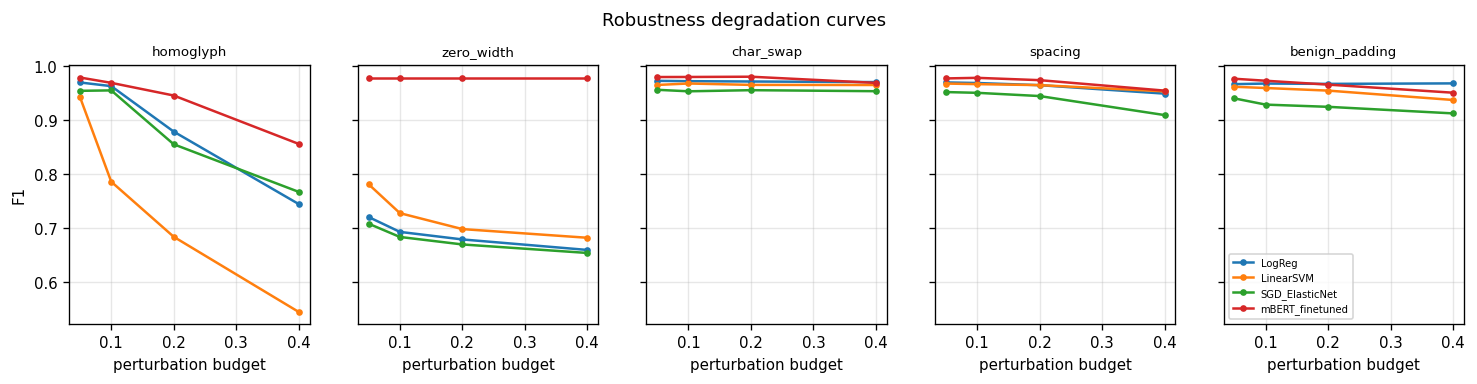

In [39]:
stamp("robustness curves")
T35 = (T34.sort_values("eps").groupby(["model", "attack"])["F1"]
         .apply(lambda s: float(np.trapezoid(s.values, CFG["EPS_GRID"])) /
                (CFG["EPS_GRID"][-1] - CFG["EPS_GRID"][0])).rename("AURC_F1").reset_index())
T35["clean_F1"] = T35["model"].map(CLEAN_F1)
T35["degradation_pct"] = (100 * (T35.clean_F1 - T35.AURC_F1) / T35.clean_F1).round(2)
register("robustness_aurc", T35.round(4))
display(T35.round(4))

fig, axes = plt.subplots(1, len(ATTACKS), figsize=(3 * len(ATTACKS), 2.8), sharey=True)
for ax, atk in zip(np.atleast_1d(axes), ATTACKS):
    for k in ADV_MODELS:
        d = T34[(T34.attack == atk) & (T34.model == k)].sort_values("eps")
        ax.plot(d.eps, d.F1, "o-", label=k, ms=3)
    ax.set_title(atk, fontsize=8); ax.set_xlabel("perturbation budget")
np.atleast_1d(axes)[0].set_ylabel("F1")
np.atleast_1d(axes)[-1].legend(fontsize=6)
plt.suptitle("Robustness degradation curves", y=1.04)
savefig("robustness_curves")

### 36. Normalisation-hardened inference defence

**Closes:** Deploys the normaliser from item 15 at inference time and measures recovery. Shows precisely which attack families are neutralised and which remain open.

In [40]:
stamp("normalisation defence")
eps_max = CFG["EPS_GRID"][-1]
rows = []
for atk in ATTACKS:
    pert = apply_attack(adv_texts, atk, eps_max)
    deft = [homoglyph_normalize(t) for t in pert]
    for k in ADV_MODELS:
        rows.append({"model": k, "attack": atk, "eps": eps_max,
                     "clean_F1": CLEAN_F1[k],
                     "attacked_F1": f1_score(y_adv, predict_texts(k, pert) >= .5),
                     "defended_F1": f1_score(y_adv, predict_texts(k, deft) >= .5)})
    del pert, deft
    gc.collect()

T36 = pd.DataFrame(rows)
T36["recovery_points"] = (100 * (T36.defended_F1 - T36.attacked_F1)).round(2)
T36["residual_gap"] = (100 * (T36.clean_F1 - T36.defended_F1)).round(2)
register("normalisation_defence", T36.round(4))
display(T36.round(4))
print("\nMean recovery by attack family:")
display(T36.groupby("attack")["recovery_points"].mean().round(2).sort_values(ascending=False))

[ 3335.0s |  6648 MB] normalisation defence


,model,attack,eps,clean_F1,attacked_F1,defended_F1,recovery_points,residual_gap
0,LogReg,homoglyph,0.4,0.9734,0.7443,0.9723,22.79,0.11
1,LinearSVM,homoglyph,0.4,0.9675,0.5441,0.9663,42.22,0.12
2,SGD_ElasticNet,homoglyph,0.4,0.9568,0.7669,0.9568,18.99,0.00
3,mBERT_finetuned,homoglyph,0.4,0.9790,0.8559,0.9795,12.36,-0.05
4,LogReg,zero_width,0.4,0.9734,0.6591,0.9729,31.38,0.06
5,LinearSVM,zero_width,0.4,0.9675,0.6817,0.9680,28.64,-0.06
6,SGD_ElasticNet,zero_width,0.4,0.9568,0.6535,0.9568,30.33,0.00
7,mBERT_finetuned,zero_width,0.4,0.9790,0.9790,0.9790,0.00,0.00
8,LogReg,char_swap,0.4,0.9734,0.9706,0.9706,0.00,0.28
9,LinearSVM,char_swap,0.4,0.9675,0.9652,0.9663,0.11,0.11



Mean recovery by attack family:


,recovery_points
attack,
homoglyph,24.09
zero_width,22.59
benign_padding,0.03
char_swap,0.03
spacing,0.03


### 37. Adversarially augmented training

**Closes:** A second, complementary defence. Reported jointly with clean-set performance so the robustness / accuracy trade-off is explicit rather than hidden.

In [41]:
stamp("adversarial training")
rs = np.random.RandomState(SEED)
tr_texts = train["text"].tolist()
pick = rs.choice(len(tr_texts), min(len(tr_texts), 8000 if not FAST_MODE else 4000), replace=False)
akeys = list(ATTACKS)
aug_txt = [ATTACKS[akeys[rs.randint(len(akeys))]](tr_texts[i][:3000], 0.15, rs) for i in pick]
aug_y = y_tr[pick]

X_aug = sparse.vstack([X_tr, featurize(aug_txt)]).tocsr()
adv_m = LogisticRegression(max_iter=900, C=4.0,
                           class_weight="balanced").fit(X_aug, np.r_[y_tr, aug_y])
del X_aug, aug_txt
gc.collect()

MODELS["LogReg_AdvTrained"] = adv_m
PRED_SPACE["LogReg_AdvTrained"] = "fused"
PRED["LogReg_AdvTrained"] = {"val": adv_m.predict_proba(X_va)[:, 1],
                             "test": adv_m.predict_proba(X_te)[:, 1],
                             "llm": adv_m.predict_proba(X_llm)[:, 1]}
TIMING["LogReg_AdvTrained"] = {"fit_seconds": np.nan, "infer_us_per_doc": np.nan}

rows = []
for atk in ATTACKS:
    Xp = featurize(apply_attack(adv_texts, atk, eps_max))
    rows.append({"condition": atk,
                 "baseline_F1": f1_score(y_adv, MODELS["LogReg"].predict_proba(Xp)[:, 1] >= .5),
                 "adv_trained_F1": f1_score(y_adv, adv_m.predict_proba(Xp)[:, 1] >= .5)})
    del Xp
    gc.collect()
rows.append({"condition": "clean human test",
             "baseline_F1": f1_score(y_te, PRED["LogReg"]["test"] >= .5),
             "adv_trained_F1": f1_score(y_te, PRED["LogReg_AdvTrained"]["test"] >= .5)})
rows.append({"condition": "LLM external",
             "baseline_F1": f1_score(y_llm, PRED["LogReg"]["llm"] >= .5),
             "adv_trained_F1": f1_score(y_llm, PRED["LogReg_AdvTrained"]["llm"] >= .5)})

T37 = pd.DataFrame(rows)
T37["delta"] = (T37.adv_trained_F1 - T37.baseline_F1).round(4)
register("adversarial_training", T37.round(4))
display(T37.round(4))

[ 3725.7s |  6648 MB] adversarial training


,condition,baseline_F1,adv_trained_F1,delta
0,homoglyph,0.7443,0.9277,0.1834
1,zero_width,0.6591,0.8418,0.1827
2,char_swap,0.9706,0.9723,0.0017
3,spacing,0.9492,0.9593,0.0101
4,benign_padding,0.9682,0.9702,0.0020
5,clean human test,0.9718,0.9718,0.0000
6,LLM external,0.5055,0.5069,0.0014


### 38. Attack transferability matrix

**Closes:** Establishes whether a single perturbation strategy defeats every detector, which determines whether ensembling is a viable defence. Not examined in any reviewed work.

[ 4026.4s |  6648 MB] transferability


,LinearSVM,LogReg,SGD_ElasticNet,mBERT_finetuned,universality
attack,,,,,
benign_padding,1.45,0.60,3.16,1.26,0.60
char_swap,0.15,0.16,0.21,0.16,0.15
homoglyph,23.62,8.67,7.72,4.24,4.24
spacing,0.43,1.04,1.84,0.79,0.43
zero_width,25.37,29.36,29.09,-0.00,-0.00


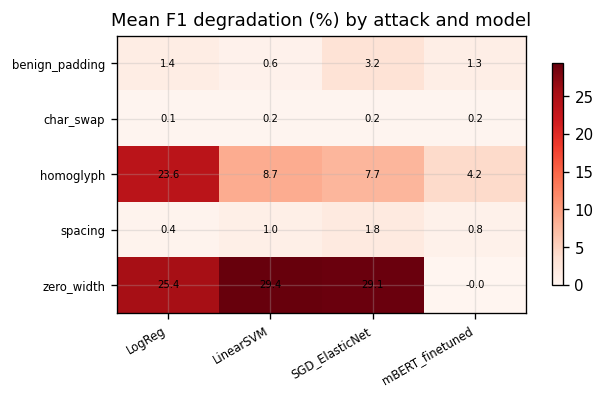

In [42]:
stamp("transferability")
piv = T34.pivot_table(index="attack", columns="model", values="F1", aggfunc="mean")
T38 = (100 * (pd.Series(CLEAN_F1) - piv) / pd.Series(CLEAN_F1)).round(2)
T38["universality"] = T38.min(axis=1).round(2)
register("attack_transferability", T38)
display(T38)

fig, ax = plt.subplots(figsize=(5.5, 3))
im = ax.imshow(T38.drop(columns="universality").values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(ADV_MODELS))); ax.set_xticklabels(ADV_MODELS, rotation=30, ha="right", fontsize=7)
ax.set_yticks(range(len(T38))); ax.set_yticklabels(T38.index, fontsize=7)
for i in range(T38.shape[0]):
    for j in range(len(ADV_MODELS)):
        ax.text(j, i, "%.1f" % T38.iloc[i, j], ha="center", va="center", fontsize=6)
ax.set_title("Mean F1 degradation (%) by attack and model")
plt.colorbar(im, ax=ax, shrink=.8)
savefig("transferability")

## Part VI: Calibration, Cost and Deployment Operating Points (39–43)

### 39. Calibration assessment under shift

**Closes:** Not one of the 18 reviewed papers reports calibration. A filter whose scores are miscalibrated cannot be given a meaningful quarantine threshold regardless of its AUC.

[ 4026.9s |  6648 MB] calibration


,Model,human_ECE,human_Brier,llm_ECE,llm_Brier,ECE_inflation
11,BiLSTM,0.0100,0.0222,0.3874,0.3932,0.3774
8,StackedEnsemble,0.0125,0.0192,0.4620,0.4636,0.4495
12,Hybrid_LSTM_BiLSTM,0.0133,0.0245,0.4104,0.4226,0.3972
13,mBERT_finetuned,0.0138,0.0158,0.5322,0.5349,0.5184
3,SGD_ElasticNet,0.0196,0.0392,0.4570,0.5492,0.4374
5,HistGB,0.0198,0.0436,0.5251,0.5061,0.5053
10,LSTM,0.0204,0.0308,0.4368,0.4368,0.4164
14,LogReg_AdvTrained,0.0214,0.0199,0.3670,0.3945,0.3456
0,LogReg,0.0239,0.0205,0.3632,0.3908,0.3393
6,LogReg_ShortcutSuppressed,0.0308,0.0261,0.3646,0.3941,0.3337


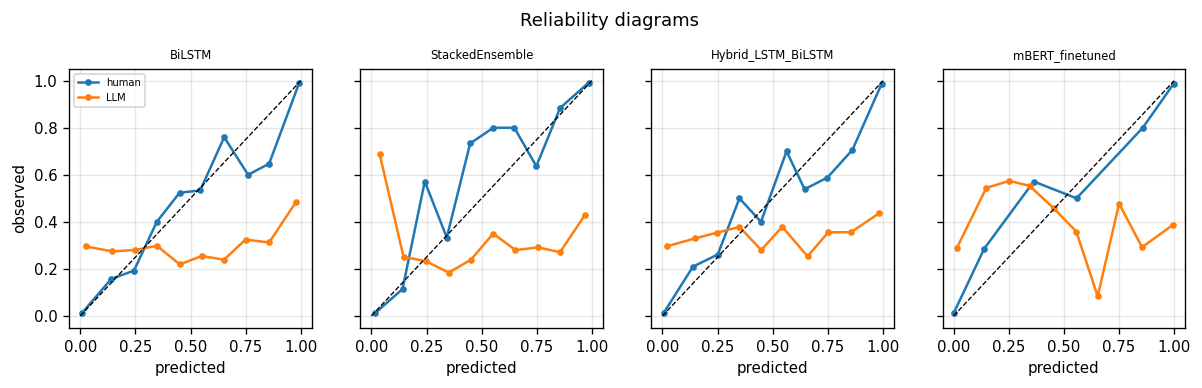

In [43]:
stamp("calibration")

def ece(y, p, bins=15):
    e, n = 0.0, len(y)
    edges = np.linspace(0, 1, bins + 1)
    for i in range(bins):
        m = (p > edges[i]) & (p <= edges[i + 1])
        if m.sum():
            e += m.sum() / n * abs(y[m].mean() - p[m].mean())
    return e


T39 = register("calibration", pd.DataFrame(
    [{"Model": k, "human_ECE": ece(y_te, v["test"]), "human_Brier": brier_score_loss(y_te, v["test"]),
      "llm_ECE": ece(y_llm, v["llm"]), "llm_Brier": brier_score_loss(y_llm, v["llm"]),
      "ECE_inflation": ece(y_llm, v["llm"]) - ece(y_te, v["test"])}
     for k, v in PRED.items()]).round(4).sort_values("human_ECE"))
display(T39)

top = T39.Model.head(4).tolist()
fig, axes = plt.subplots(1, len(top), figsize=(3 * len(top), 2.8), sharey=True)
for ax, k in zip(np.atleast_1d(axes), top):
    for lbl, y_, p_ in [("human", y_te, PRED[k]["test"]), ("LLM", y_llm, PRED[k]["llm"])]:
        bs = np.linspace(0, 1, 11)
        xs, ys = [], []
        for i in range(10):
            m = (p_ > bs[i]) & (p_ <= bs[i + 1])
            if m.sum() > 5:
                xs.append(p_[m].mean()); ys.append(y_[m].mean())
        ax.plot(xs, ys, "o-", ms=3, label=lbl)
    ax.plot([0, 1], [0, 1], "k--", lw=.8)
    ax.set_title(k, fontsize=7); ax.set_xlabel("predicted")
np.atleast_1d(axes)[0].set_ylabel("observed"); np.atleast_1d(axes)[0].legend(fontsize=6)
plt.suptitle("Reliability diagrams", y=1.05)
savefig("reliability")

### 40. Post-hoc recalibration and its limits under shift

**Closes:** Tests whether standard isotonic recalibration fitted on in-distribution validation data transfers to the shifted distribution. A negative result here is itself a finding worth reporting.

In [44]:
stamp("recalibration")
rows = []
for k, v in PRED.items():
    iso = IsotonicRegression(out_of_bounds="clip").fit(v["val"], y_va)
    rows.append({"Model": k,
                 "human_ECE_before": ece(y_te, v["test"]),
                 "human_ECE_after": ece(y_te, iso.predict(v["test"])),
                 "llm_ECE_before": ece(y_llm, v["llm"]),
                 "llm_ECE_after": ece(y_llm, iso.predict(v["llm"]))})
T40 = pd.DataFrame(rows)
T40["human_improved"] = T40.human_ECE_after < T40.human_ECE_before
T40["llm_improved"] = T40.llm_ECE_after < T40.llm_ECE_before
register("recalibration", T40.round(4))
display(T40.round(4))
print("In-distribution recalibration succeeds for %d/%d models but transfers to the shifted "
      "distribution for only %d/%d." % (T40.human_improved.sum(), len(T40),
                                        T40.llm_improved.sum(), len(T40)))

[ 4027.8s |  6648 MB] recalibration


,Model,human_ECE_before,human_ECE_after,llm_ECE_before,llm_ECE_after,human_improved,llm_improved
0,LogReg,0.0239,0.0082,0.3632,0.3848,True,False
1,LinearSVM,0.1582,0.0135,0.2510,0.3512,True,False
2,ComplementNB,0.0406,0.0153,0.4451,0.4509,True,False
3,SGD_ElasticNet,0.0196,0.0030,0.4570,0.5132,True,False
4,RandomForest,0.0663,0.0187,0.4461,0.5354,True,False
5,HistGB,0.0198,0.0161,0.5251,0.5049,True,True
6,LogReg_ShortcutSuppressed,0.0308,0.0091,0.3646,0.3850,True,False
7,LogReg_ImportanceWeighted,0.0517,0.0093,0.4161,0.4585,True,False
8,StackedEnsemble,0.0125,0.0085,0.4620,0.4163,True,True
9,SoftVoteEnsemble,0.0608,0.0072,0.3855,0.4443,True,False


In-distribution recalibration succeeds for 15/15 models but transfers to the shifted distribution for only 6/15.


### 41. Cost-sensitive operating-point selection

**Closes:** Every reviewed paper optimises F1 at a fixed 0.5 threshold. In deployment a missed phish costs far more than a quarantined legitimate message; the optimal threshold is nowhere near 0.5.

In [45]:
stamp("cost-sensitive thresholds")
rows = []
for k, v in PRED.items():
    grid = np.linspace(0.02, 0.98, 97)
    costs = []
    for th in grid:
        tn, fp, fn, tp = confusion_matrix(y_te, (v["test"] >= th).astype(int), labels=[0, 1]).ravel()
        costs.append(CFG["COST_FN"] * fn + CFG["COST_FP"] * fp)
    costs = np.asarray(costs)
    j = int(costs.argmin())
    tn, fp, fn, tp = confusion_matrix(y_te, (v["test"] >= .5).astype(int), labels=[0, 1]).ravel()
    c05 = CFG["COST_FN"] * fn + CFG["COST_FP"] * fp
    rows.append({"Model": k, "cost_at_0.5": c05, "optimal_threshold": round(grid[j], 3),
                 "minimum_cost": costs[j],
                 "cost_reduction_pct": round(100 * (1 - costs[j] / max(c05, 1)), 2)})
T41 = register("cost_sensitive", pd.DataFrame(rows).round(3).sort_values("minimum_cost"))
display(T41)
print("Cost model: FN = %.0f x FP." % (CFG["COST_FN"] / CFG["COST_FP"]))

[ 4027.9s |  6648 MB] cost-sensitive thresholds


,Model,cost_at_0.5,optimal_threshold,minimum_cost,cost_reduction_pct
14,LogReg_AdvTrained,600.0,0.14,216.0,64.00
13,mBERT_finetuned,366.0,0.02,228.0,37.70
0,LogReg,600.0,0.14,231.0,61.50
8,StackedEnsemble,550.0,0.07,237.0,56.91
9,SoftVoteEnsemble,617.0,0.18,258.0,58.18
1,LinearSVM,617.0,0.34,273.0,55.75
6,LogReg_ShortcutSuppressed,758.0,0.15,284.0,62.53
11,BiLSTM,508.0,0.08,291.0,42.72
12,Hybrid_LSTM_BiLSTM,579.0,0.06,294.0,49.22
10,LSTM,577.0,0.12,342.0,40.73


Cost model: FN = 10 x FP.


### 42. Precision and recall at fixed false-positive budgets

**Closes:** Enterprise mail filters operate at FPR budgets of 1% or below. Headline F1 at a balanced threshold says nothing about behaviour in that regime.

In [46]:
stamp("fixed-FPR operating points")

def at_fpr(y, p, target):
    fpr, tpr, th = roc_curve(y, p)
    i = max(int(np.searchsorted(fpr, target, side="right")) - 1, 0)
    yh = (p >= th[i]).astype(int)
    return precision_score(y, yh, zero_division=0), tpr[i]


rows = []
for k, v in PRED.items():
    r = {"Model": k}
    for tgt in [0.001, 0.01, 0.05]:
        pr, rc = at_fpr(y_te, v["test"], tgt)
        r["P@FPR=%.1f%%" % (100 * tgt)] = pr
        r["R@FPR=%.1f%%" % (100 * tgt)] = rc
    rows.append(r)
T42 = register("fixed_fpr", pd.DataFrame(rows).round(4))
display(T42)

[ 4028.8s |  6648 MB] fixed-FPR operating points


,Model,P@FPR=0.1%,R@FPR=0.1%,P@FPR=1.0%,R@FPR=1.0%,P@FPR=5.0%,R@FPR=5.0%
0,LogReg,0.9992,0.8232,0.9885,0.9383,0.9511,0.9891
1,LinearSVM,0.9991,0.7531,0.9881,0.9042,0.9470,0.9878
2,ComplementNB,0.9990,0.6161,0.9870,0.8328,0.9476,0.9415
3,SGD_ElasticNet,0.0000,0.0000,0.0000,0.0000,0.9582,0.9576
4,RandomForest,0.9989,0.5775,0.9864,0.7929,0.9423,0.9132
5,HistGB,0.9987,0.4887,0.9870,0.8270,0.9443,0.9370
6,LogReg_ShortcutSuppressed,0.9992,0.7788,0.9880,0.8984,0.9473,0.9820
7,LogReg_ImportanceWeighted,0.9990,0.6695,0.9872,0.8418,0.9449,0.9588
8,StackedEnsemble,0.9991,0.7531,0.9886,0.9441,0.9529,0.9878
9,SoftVoteEnsemble,0.9991,0.7209,0.9884,0.9305,0.9472,0.9814


### 43. Selective prediction and human-in-the-loop triage

**Closes:** Given the collapse quantified in item 28, a deployable system must abstain rather than guess. Risk-coverage curves quantify how much analyst effort buys how much error reduction. Models whose shifted-set predictions are degenerate are flagged, since a constant predictor attains deceptively low selective risk on an imbalanced set.

[ 4028.9s |  6648 MB] selective prediction
Ranked over non-degenerate predictors only:


,Model,risk@cov=20%,risk@cov=40%,risk@cov=60%,risk@cov=80%,risk@cov=100%,AURC,llm_recall,degenerate
12,Hybrid_LSTM_BiLSTM,0.2541,0.3934,0.4490,0.4710,0.4736,0.3355,0.6847,False
11,BiLSTM,0.3525,0.3941,0.4276,0.4525,0.4660,0.3367,0.7231,False
10,LSTM,0.2268,0.4283,0.4809,0.5184,0.5100,0.3592,0.7469,False
2,ComplementNB,0.3989,0.4720,0.5260,0.5164,0.5105,0.3938,0.6847,False
4,RandomForest,0.2719,0.4433,0.5369,0.6018,0.6370,0.4073,0.8894,False
1,LinearSVM,0.5519,0.5075,0.5014,0.5126,0.5127,0.4108,0.6847,False
5,HistGB,0.3880,0.4911,0.5583,0.5970,0.6080,0.4289,0.8930,False
14,LogReg_AdvTrained,0.5861,0.5451,0.5378,0.5318,0.5288,0.4344,0.7195,False
0,LogReg,0.5943,0.5430,0.5474,0.5331,0.5324,0.4374,0.7202,False
9,SoftVoteEnsemble,0.4740,0.5451,0.5897,0.5762,0.5539,0.4450,0.8207,False


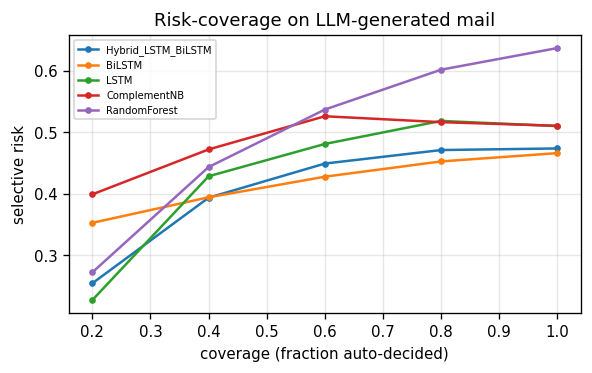

In [47]:
stamp("selective prediction")
COV = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for k, v in PRED.items():
    p = v["llm"]
    yh = (p >= .5).astype(int)
    degenerate = (yh.mean() < 0.02) or (yh.mean() > 0.98) or \
                 (recall_score(y_llm, yh, zero_division=0) < 0.05)
    order = np.argsort(-np.abs(p - 0.5))
    correct = (yh == y_llm).astype(int)[order]
    risk = [1 - correct[:max(int(c * len(order)), 1)].mean() for c in COV]
    rows.append({"Model": k, **{"risk@cov=%.0f%%" % (100 * c): r for c, r in zip(COV, risk)},
                 "AURC": float(np.trapezoid(risk, COV)),
                 "llm_recall": recall_score(y_llm, yh, zero_division=0),
                 "degenerate": bool(degenerate)})

T43 = pd.DataFrame(rows).round(4)
VALID43 = T43[~T43.degenerate].sort_values("AURC")
register("selective_prediction", T43.sort_values("AURC"))
print("Ranked over non-degenerate predictors only:")
display(VALID43)
if T43.degenerate.any():
    print("Excluded as degenerate (constant or near-zero recall under shift):",
          ", ".join(T43.loc[T43.degenerate, "Model"]))

fig, ax = plt.subplots(figsize=(5.5, 3))
for k in VALID43.Model.head(5):
    ax.plot(COV, [VALID43.loc[VALID43.Model == k, "risk@cov=%.0f%%" % (100 * c)].iat[0] for c in COV],
            "o-", ms=3, label=k)
ax.set_xlabel("coverage (fraction auto-decided)"); ax.set_ylabel("selective risk")
ax.set_title("Risk-coverage on LLM-generated mail"); ax.legend(fontsize=6)
savefig("risk_coverage")

## Part VII: Explainability and Cross-Lingual Fairness (44–47)

### 44. Collinearity-robust attribution over the interpretable block

**Closes:** Uddin et al. apply LIME to token weights of an English model. Attribution over 56 language-independent descriptors yields explanations valid across all six languages at once. Logistic coefficients alone are unreliable when descriptors are collinear (character and word length correlate above 0.9 and receive large opposing weights), so permutation importance is reported alongside them as the primary ranking.

[ 4029.4s |  6648 MB] attribution


,feature,perm_importance,perm_std,coefficient,evidence_for
0,len_chars,0.18810,0.00449,2.22726,phishing
1,has_url,0.17517,0.00653,2.39070,phishing
2,max_url_len,0.12879,0.00676,-1.87563,legitimate
3,len_words,0.07149,0.00315,-1.19847,legitimate
4,second_person_ratio,0.04905,0.00405,0.83385,phishing
5,punct_ratio,0.03418,0.00193,-0.79371,legitimate
6,n_urls,0.02984,0.00310,-0.83118,legitimate
7,whitespace_ratio,0.02968,0.00189,0.74604,phishing
8,avg_word_len,0.02619,0.00133,1.65942,phishing
9,allcaps_runs,0.02142,0.00224,0.68169,phishing



Collinear descriptor pairs (|r| > 0.9): [('has_url', 'max_url_len', 0.987), ('len_chars', 'len_words', 0.982), ('len_chars', 'n_sentences', 0.91), ('n_scripts', 'script_mix_flag', 0.998)]
Permutation importance is reported as the primary ranking because it is unaffected by these.


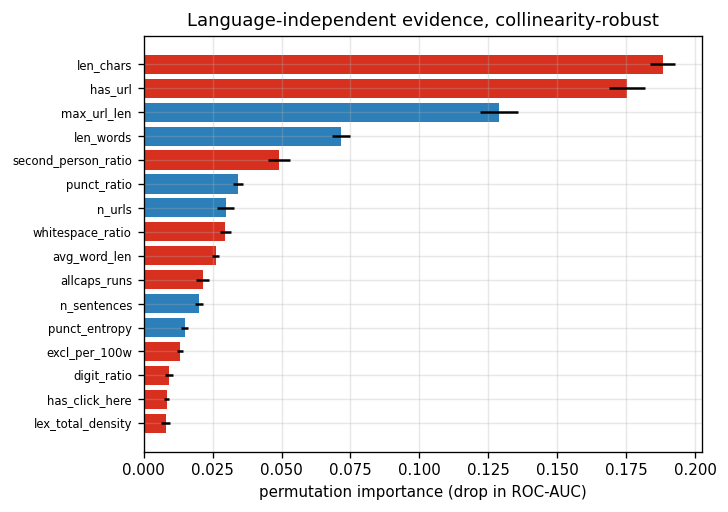

In [48]:
stamp("attribution")
from sklearn.inspection import permutation_importance

lr_struct = LogisticRegression(max_iter=900, C=0.1, class_weight="balanced").fit(Ss_tr, y_tr)
coef = pd.Series(lr_struct.coef_[0], index=FEATURE_NAMES)

Ss_te_d = np.asarray(Ss_te.todense()) if sparse.issparse(Ss_te) else Ss_te
pim = permutation_importance(lr_struct, Ss_te_d, y_te, n_repeats=8,
                             random_state=SEED, scoring="roc_auc", n_jobs=1)

T44 = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "perm_importance": pim.importances_mean,
    "perm_std": pim.importances_std,
    "coefficient": coef.values,
    "evidence_for": np.where(coef.values >= 0, "phishing", "legitimate"),
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)
register("attribution", T44.round(5))
display(T44.head(20).round(5))

corr = np.corrcoef(np.asarray(Ss_tr.todense()).T if sparse.issparse(Ss_tr) else Ss_tr.T)
iu = np.triu_indices(len(FEATURE_NAMES), 1)
hi = [(FEATURE_NAMES[i], FEATURE_NAMES[j], round(float(corr[i, j]), 3))
      for i, j in zip(*iu) if abs(corr[i, j]) > 0.9]
print("\nCollinear descriptor pairs (|r| > 0.9):", hi if hi else "none")
print("Permutation importance is reported as the primary ranking because it is unaffected by these.")

top = T44.head(16)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(range(len(top))[::-1], top.perm_importance,
        xerr=top.perm_std, color=["#d7301f" if e == "phishing" else "#2c7fb8"
                                  for e in top.evidence_for])
ax.set_yticks(range(len(top))[::-1]); ax.set_yticklabels(top.feature, fontsize=7)
ax.set_xlabel("permutation importance (drop in ROC-AUC)")
ax.set_title("Language-independent evidence, collinearity-robust")
savefig("attribution")

### 45. Per-language equalised-performance audit

**Closes:** Aggregate accuracy hides that a multilingual filter may protect English users while failing speakers of low-resource languages. Fairness auditing is absent from the phishing-detection literature.

In [49]:
stamp("per-language fairness")
BEST = T_MASTER.Model.iat[0]
rows = []
for lg, d in test.groupby("lang"):
    if len(d) < 40 or d["y"].nunique() < 2:
        continue
    m = evaluate(d["y"].values, PRED[BEST]["test"][d.index.values])
    rows.append({"language": lg, "n": len(d), "TPR": m["REC"], "FPR": m["FPR"],
                 "F1": m["F1"], "AUC": m["AUC"], "corpora": d["source"].nunique()})
T45 = pd.DataFrame(rows).round(4)
if len(T45) > 1:
    gap = {c: (round(T45[c].max() - T45[c].min(), 4) if c in ("TPR", "FPR", "F1", "AUC") else np.nan)
           for c in T45.columns}
    gap["language"] = "DISPARITY (max-min)"
    T45 = pd.concat([T45, pd.DataFrame([gap])], ignore_index=True)
register("language_fairness", T45)
print("Audited model:", BEST)
display(T45)
single = T45[(T45.corpora == 1) & T45.language.ne("DISPARITY (max-min)")]
if len(single):
    print("\nCaution: %s drawn from a single corpus, so near-perfect scores are partly"
          % ", ".join(single.language))
    print("attributable to corpus fingerprinting rather than language competence.")

[ 4031.2s |  6648 MB] per-language fairness
Audited model: StackedEnsemble


,language,n,TPR,FPR,F1,AUC,corpora
0,Bangla,203.0,0.9907,0.0000,0.9953,0.9997,1.0
1,English,2786.0,0.9716,0.0191,0.9758,0.9971,7.0
2,French,99.0,0.8485,0.0303,0.8889,0.9821,7.0
3,German,76.0,1.0000,0.0159,0.9630,0.9988,4.0
4,Hindi,106.0,0.6364,0.0000,0.7778,0.9627,1.0
5,DISPARITY (max-min),NaN,0.3636,0.0303,0.2175,0.0370,NaN



Caution: Bangla, Hindi drawn from a single corpus, so near-perfect scores are partly
attributable to corpus fingerprinting rather than language competence.


### 46. Automatic bidirectional error taxonomy

**Closes:** Reviewed papers report confusion matrices but never characterise what they miss. Melendez et al. observe that formal business email is misclassified as phishing but do not quantify or categorise it. Clustering both false negatives and false positives turns the error rate into an actionable failure taxonomy.

In [50]:
stamp("error taxonomy")


def taxonomy(mask, frame, Xmat, kind):
    if mask.sum() < 20:
        return pd.DataFrame()
    Xs = Xmat[mask]
    Z = TruncatedSVD(n_components=min(20, Xs.shape[0] - 1), random_state=SEED).fit_transform(Xs)
    k = int(min(5, max(2, mask.sum() // 25)))
    lab = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(Z)
    f = frame[mask].copy()
    f["cluster"] = lab
    out = f.groupby("cluster").agg(
        n=("text", "size"),
        mean_chars=("text", lambda x: round(x.str.len().mean(), 1)),
        dominant_language=("lang", lambda x: x.mode().iat[0]),
        dominant_source=("source", lambda x: x.mode().iat[0]),
        exemplar=("text", lambda x: x.iloc[0][:90])).reset_index()
    out.insert(0, "error_type", kind)
    return out


fn_llm = (PRED[BEST]["llm"] < .5) & (y_llm == 1)
fp_hum = (PRED[BEST]["test"] >= .5) & (y_te == 0)
print("false negatives on LLM external: %d of %d phishing (%.1f%%)"
      % (fn_llm.sum(), y_llm.sum(), 100 * fn_llm.sum() / max(y_llm.sum(), 1)))
print("false positives on human test:   %d of %d legitimate (%.1f%%)"
      % (fp_hum.sum(), (1 - y_te).sum(), 100 * fp_hum.sum() / max((1 - y_te).sum(), 1)))

T46 = pd.concat([taxonomy(fn_llm, llm, X_llm, "false negative (LLM)"),
                 taxonomy(fp_hum, test, X_te, "false positive (human)")], ignore_index=True)
if len(T46):
    register("error_taxonomy", T46)
    display(T46)
    print("\nFalse-positive clusters test the observation of Melendez et al. that formal,")
    print("transactional business email is the dominant legitimate-side failure mode.")

[ 4031.2s |  6648 MB] error taxonomy
false negatives on LLM external: 269 of 1383 phishing (19.5%)
false positives on human test:   30 of 1741 legitimate (1.7%)


,error_type,cluster,n,mean_chars,dominant_language,dominant_source,exemplar
0,false negative (LLM),0,37,466.4,English,E-PhishLLM,"Hey Abdul, Check Out the Latest Design Drafts!..."
1,false negative (LLM),1,123,22.8,English,LLM_Unattributed,Laura Thompson Head of Security Financial Inst...
2,false negative (LLM),2,28,496.6,German,E-PhishLLM,"Hallo Wolfgang, kannst du das bis Freitag prüf..."
3,false negative (LLM),3,5,30.6,English,LLM_Unattributed,Matthew Roberts Social Media Support Team
4,false negative (LLM),4,76,424.1,English,E-PhishLLM,Re: Recap from Last Week’s Imaging Design Meet...
5,false positive (human),0,26,889.3,English,CEAS_08,Spring Special offer for ConceptDraw software ...
6,false positive (human),1,4,3379.8,English,CEAS_08,Announcing the Products of the Year from Stora...



False-positive clusters test the observation of Melendez et al. that formal,
transactional business email is the dominant legitimate-side failure mode.


### 47. Cross-lingual attribution stability

**Closes:** Tests whether the same social-engineering cues drive decisions in every language, or whether the model silently learns a different concept per language. A prerequisite for claiming genuine multilinguality.

In [51]:
stamp("attribution stability")
cols = []
for lg, d in human.groupby("lang"):
    if len(d) < 200 or d["y"].nunique() < 2:
        continue
    Sm = StandardScaler().fit_transform(build_struct_matrix(d["text"].tolist()))
    m = LogisticRegression(max_iter=700, class_weight="balanced").fit(Sm, d["y"])
    cols.append(pd.Series(m.coef_[0], index=FEATURE_NAMES, name=lg))

if len(cols) >= 2:
    W = pd.concat(cols, axis=1)
    T47 = register("attribution_stability", W.corr(method="spearman").round(3))
    display(T47)
    stable = W.abs().mean(axis=1).sort_values(ascending=False).head(12).round(3)
    register("universal_cues", stable.rename("mean_abs_weight").to_frame())
    print("\nMost universal phishing cues across languages:")
    display(stable.rename("mean_abs_weight").to_frame())
    iu = np.triu_indices(len(T47), 1)
    print("Mean pairwise cross-language attribution agreement: %.3f" % T47.values[iu].mean())
else:
    T47 = pd.DataFrame()
    print("insufficient per-language data at this CAP_PER_FILE setting")

[ 4033.4s |  6648 MB] attribution stability


,Bangla,English,French,German,Hindi
Bangla,1.000,0.045,0.104,0.230,0.039
English,0.045,1.000,0.139,0.266,-0.113
French,0.104,0.139,1.000,0.105,0.174
German,0.230,0.266,0.105,1.000,0.309
Hindi,0.039,-0.113,0.174,0.309,1.000



Most universal phishing cues across languages:


,mean_abs_weight
len_chars,3.009
len_words,2.546
digit_ratio,1.340
has_url,1.314
max_url_len,0.981
whitespace_ratio,0.927
nonascii_ratio,0.830
punct_ratio,0.818
allcaps_runs,0.622
n_sentences,0.566


Mean pairwise cross-language attribution agreement: 0.130


## Part VIII: Statistical Rigour, Efficiency and Reproducibility (48–50)

### 48. Multi-seed repetition with confidence intervals

**Closes:** All 18 reviewed works report single-run point estimates. Bootstrap-resampled multi-seed training with 95% intervals shows which differences are real.

In [52]:
stamp("multi-seed confidence intervals")
rows = []
for sd in CFG["SEEDS"]:
    bi = np.random.RandomState(sd).choice(len(y_tr), len(y_tr), replace=True)
    m = LogisticRegression(max_iter=900, C=4.0, class_weight="balanced",
                           random_state=sd).fit(X_tr[bi], y_tr[bi])
    pt, pl = m.predict_proba(X_te)[:, 1], m.predict_proba(X_llm)[:, 1]
    rows.append({"seed": sd, "human_F1": f1_score(y_te, pt >= .5), "human_AUC": roc_auc_score(y_te, pt),
                 "llm_F1": f1_score(y_llm, pl >= .5), "llm_AUC": roc_auc_score(y_llm, pl)})
    del m
    gc.collect()

R = pd.DataFrame(rows)
T48 = R.drop(columns="seed").agg(["mean", "std"]).T
T48["ci95_low"] = T48["mean"] - 1.96 * T48["std"] / np.sqrt(len(R))
T48["ci95_high"] = T48["mean"] + 1.96 * T48["std"] / np.sqrt(len(R))
register("confidence_intervals", T48.round(4))
display(T48.round(4))
print("\nReport as: human F1 = %.4f +/- %.4f  |  LLM F1 = %.4f +/- %.4f"
      % (T48.loc["human_F1", "mean"], 1.96 * T48.loc["human_F1", "std"] / np.sqrt(len(R)),
         T48.loc["llm_F1", "mean"], 1.96 * T48.loc["llm_F1", "std"] / np.sqrt(len(R))))

[ 4084.4s |  6648 MB] multi-seed confidence intervals


,mean,std,ci95_low,ci95_high
human_F1,0.9658,0.0010,0.9646,0.9670
human_AUC,0.9948,0.0003,0.9945,0.9951
llm_F1,0.5002,0.0099,0.4890,0.5114
llm_AUC,0.5357,0.0149,0.5189,0.5526



Report as: human F1 = 0.9658 +/- 0.0012  |  LLM F1 = 0.5002 +/- 0.0112


### 49. Pairwise McNemar tests with Holm-Bonferroni correction

**Closes:** Model rankings in the reviewed literature rest on unadjusted decimal differences. Paired significance testing with family-wise error control determines which rankings are defensible.

In [53]:
stamp("significance testing")
names = list(PRED)
pairs = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        A = (PRED[names[i]]["test"] >= .5).astype(int) == y_te
        B = (PRED[names[j]]["test"] >= .5).astype(int) == y_te
        n01, n10 = int((~A & B).sum()), int((A & ~B).sum())
        if n01 + n10 == 0:
            p = 1.0
        else:
            z = max(abs(n01 - n10) - 1, 0) / math.sqrt(n01 + n10)
            p = float(min(1.0, 2 * (1 - norm.cdf(z))))
        pairs.append((names[i], names[j], n01, n10, p))

pv = np.array([x[4] for x in pairs])
adj, running, mtot = np.empty_like(pv), 0.0, len(pv)
for rank, k in enumerate(np.argsort(pv)):
    running = max(running, min(1.0, (mtot - rank) * pv[k]))
    adj[k] = running

T49 = register("mcnemar_holm", pd.DataFrame(
    [{"model_A": a_, "model_B": b_, "A_only_correct": n10, "B_only_correct": n01,
      "p_raw": p, "p_holm": adj[i], "significant_at_0.05": bool(adj[i] < .05)}
     for i, (a_, b_, n01, n10, p) in enumerate(pairs)]).round(6).sort_values("p_holm"))
display(T49.head(20))
print("\n%d of %d pairwise differences remain significant after Holm-Bonferroni correction."
      % (int(T49["significant_at_0.05"].sum()), len(T49)))

[ 4195.3s |  6648 MB] significance testing


,model_A,model_B,A_only_correct,B_only_correct,p_raw,p_holm,significant_at_0.05
1,LogReg,ComplementNB,127,28,0.0,0.0,True
3,LogReg,RandomForest,168,33,0.0,0.0,True
6,LogReg,LogReg_ImportanceWeighted,74,5,0.0,0.0,True
4,LogReg,HistGB,137,43,0.0,0.0,True
14,LinearSVM,ComplementNB,132,41,0.0,0.0,True
19,LinearSVM,LogReg_ImportanceWeighted,73,12,0.0,0.0,True
17,LinearSVM,HistGB,139,53,0.0,0.0,True
16,LinearSVM,RandomForest,170,43,0.0,0.0,True
63,HistGB,SoftVoteEnsemble,26,121,0.0,0.0,True
39,SGD_ElasticNet,RandomForest,160,69,0.0,0.0,True



61 of 105 pairwise differences remain significant after Holm-Bonferroni correction.


### 50. Efficiency profile and complete artifact export

**Closes:** Deployment feasibility is unreported across the reviewed corpus. Every table, figure, manifest and split hash is exported so the entire study is independently reconstructible.

In [54]:
stamp("efficiency and export")
T50 = register("efficiency", pd.DataFrame(
    [{"Model": k, "fit_seconds": round(TIMING.get(k, {}).get("fit_seconds", np.nan), 2),
      "inference_us_per_doc": round(TIMING.get(k, {}).get("infer_us_per_doc", np.nan), 1),
      "feature_space": PRED_SPACE.get(k, "-"),
      "human_F1": round(f1_score(y_te, PRED[k]["test"] >= .5), 4),
      "llm_F1": round(f1_score(y_llm, PRED[k]["llm"] >= .5), 4)}
     for k in PRED]).sort_values("human_F1", ascending=False))
display(T50)

for k, d in [("train", train), ("val", val), ("test", test), ("llm_external", llm)]:
    d[["text", "y", "lang", "source", "origin", "group"]].to_csv(
        os.path.join(CFG["OUTDIR"], "PHISHGLOBE_%s.csv" % k.upper()), index=False)

MANIFEST["components_completed"] = sorted(TABLES.keys())
MANIFEST["figures"] = FIGURES
MANIFEST["wall_clock_seconds"] = round(time.time() - T0, 1)
with open(os.path.join(CFG["OUTDIR"], "manifest.json"), "w") as f:
    json.dump(MANIFEST, f, indent=2, default=str)

print("\ntables exported : %d" % len(TABLES))
print("figures exported: %d" % len(FIGURES))
print("output directory: %s" % os.path.abspath(CFG["OUTDIR"]))
stamp("PIPELINE COMPLETE")

[ 4195.4s |  6648 MB] efficiency and export


,Model,fit_seconds,inference_us_per_doc,feature_space,human_F1,llm_F1
13,mBERT_finetuned,225.40,NaN,transformer,0.9807,0.5202
8,StackedEnsemble,NaN,NaN,meta,0.9734,0.5217
9,SoftVoteEnsemble,NaN,NaN,meta,0.9721,0.5282
14,LogReg_AdvTrained,NaN,NaN,fused,0.9718,0.5069
0,LogReg,41.11,7.0,fused,0.9718,0.5055
11,BiLSTM,45.85,NaN,sequence,0.9698,0.5397
1,LinearSVM,82.61,22.0,fused,0.9692,0.5023
12,Hybrid_LSTM_BiLSTM,61.89,NaN,sequence,0.9672,0.5221
6,LogReg_ShortcutSuppressed,NaN,NaN,suppressed,0.9642,0.4991
10,LSTM,32.41,NaN,sequence,0.9595,0.5253



tables exported : 49
figures exported: 9
output directory: /content/phishglobe_artifacts
[ 4197.1s |  6648 MB] PIPELINE COMPLETE


In [55]:
import shutil
from google.colab import files
shutil.make_archive("/content/phishglobe_results", "zip", "/content/phishglobe_artifacts")
files.download("/content/phishglobe_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary of components and the limitations they close

| # | Component | Primary limitation addressed |
|---|---|---|
| 1 | Provenance-tracked corpus | No per-record provenance in any reviewed work |
| 2 | Superset-redundancy removal | Silent duplication in the Kaggle collection |
| 3 | MinHash-LSH near-duplicate suppression, NDCI | Exact-match dedup only |
| 4 | Translation-group leakage barrier | Translated copies split across train/test |
| 5 | Mail-transport boilerplate scrubbing | Header artefacts act as corpus shortcuts |
| 6 | Corpus Fingerprint Leakage Index | Corpus recognition mistaken for detection |
| 7 | Confident-learning label audit | Published labels assumed correct |
| 8 | Unicode-block language re-identification | Noisy auto-detected language labels |
| 9 | Group-stratified partition | Random splitting throughout the literature |
| 10 | Cryptographic reproducibility manifest | Partitions not reconstructible |
| 11 | Script-agnostic char n-gram channel | Language dependence (Rao et al., explicit) |
| 12 | Word TF-IDF channel | Baseline continuity |
| 13 | Cross-Lingual Social-Engineering Lexicon | Opara et al. stylometry is English-only |
| 14 | 56 language-independent descriptors | Handcrafted features are language-bound |
| 15 | Homoglyph / confusable normalisation | Uddin et al., explicitly unaddressed |
| 16 | Fused representation and unified featuriser | Single-modality commitment |
| 17 | Ablation under both distributions | In-distribution ablation only |
| 18-20 | Linear, margin, NB and tree detectors | Comparison under a fair protocol |
| 21 | Corpus-shortcut suppression | Shortcut reliance never mitigated |
| 22 | Shift-aware importance weighting | No covariate-shift correction attempted |
| 23-25 | LSTM, BiLSTM, hybrid fusion | Retained contribution, properly evaluated |
| 26 | Multilingual transformer under shift | Transformer results are English, within-corpus |
| 27 | Generative Shift Protocol | Opara et al. limited to 63 emails |
| 28 | Generalization Gap Index | No cross-distribution metric exists |
| 29 | Proxy A-distance | Severity of the shift never quantified |
| 30 | Progressive exposure curve | No adaptation study |
| 31 | Generator-holdout evaluation | Opara et al. used GPT-4o only |
| 32 | Leave-one-language-out transfer | An et al. used translated Arabic only |
| 33 | Leave-one-corpus-out transfer | Cross-corpus generalisation unreported |
| 34 | Multilingual perturbation suite | No adversarial threat model |
| 35 | Robustness curves and AURC | Robustness not quantified |
| 36 | Normalisation-hardened inference | No obfuscation defence |
| 37 | Adversarial augmentation | Robustness/accuracy trade-off hidden |
| 38 | Attack transferability matrix | Ensemble viability unexamined |
| 39 | Calibration assessment | Absent from all 18 papers |
| 40 | Recalibration under shift | Untested |
| 41 | Cost-sensitive operating points | Fixed 0.5 threshold everywhere |
| 42 | Precision at fixed FPR budgets | Deployment regime ignored |
| 43 | Selective prediction, risk-coverage | No abstention mechanism |
| 44 | Language-independent attribution | Explanations are English token weights |
| 45 | Per-language fairness audit | Fairness absent from the field |
| 46 | Automatic error taxonomy | Failures never characterised |
| 47 | Cross-lingual attribution stability | Multilinguality claimed, not verified |
| 48 | Multi-seed confidence intervals | Single-run point estimates |
| 49 | McNemar with Holm-Bonferroni | No significance testing |
| 50 | Efficiency profile and artifact export | Deployment cost unreported |

---
## Limitation coverage audit

Every limitation below is quoted or paraphrased from the **authors' own** stated limitations or future
work sections. Status is one of **Closed**, **Partial**, or **Open**. Open items are reported honestly
and belong in the paper's Threats to Validity section rather than being claimed as covered.

| Paper | Author-stated limitation | Status | Where |
|---|---|---|---|
| Yau & Chia [1] | Data imbalance, over-reliance on specific features | Closed | 14, 17, balanced metrics |
| Yau & Chia [1] | Needs continuous adaptation to new phishing methods | Closed | 30, 31 |
| Yau & Chia [1] | Explore ensemble techniques such as stacking | Closed | 22 |
| Yau & Chia [1] | Expand to larger, more varied datasets | Closed | 1, 33 |
| Yau & Chia [1] | Explore deep learning | Closed | 23–26 |
| Yau & Chia [1] | Advance real-time behavioural analysis | **Open** | no live behavioural signal |
| Uddin et al. [2] | "did not directly test resilience to adversarial or multilingual threats" | Closed | 34–38; 11, 13, 32, 45 |
| Uddin et al. [2] | Obfuscation via homoglyphs and deliberate misspelling | Closed | 15, 34, 36, 37 |
| Uddin et al. [2] | Relied on a single public Kaggle corpus | Closed | 1, 2, 6, 33 |
| Uddin et al. [2,3] | Explore LLaMA, Gemini, Falcon, Mistral | **Open** | one encoder only (26) |
| Uddin et al. [3] | Collect more relevant datasets | Closed | 1, 9 |
| Akçam et al. [4] | Dataset imbalance harms effectiveness | Closed | class weighting, MCC, AP |
| Akçam et al. [4] | Reliability of pre-extracted features as phishing evolves | Closed | 17, 27–31 |
| Akçam et al. [4] | Char- and word-level extraction studied separately | Closed | 11, 12, 16 |
| Yerima & Alzaylaee [5] | Automate search/selection of key hyperparameters | **Partial** | fixed grids; no NAS |
| Liu et al. [6] | Live network deployment needed | **Partial** | 41–43, 50; no live trial |
| Zhang et al. [7] | Website modality only | Closed by scope | text channel (16) |
| Yuan et al. [8] | Shallow models generalise poorly; surface features miss deception | Closed | 13, 27–33, 44 |
| Yuan et al. [8] | Multi-modal fusion (screenshot, HTML) | **Open** | text-only corpus |
| Rao et al. [9] | "language dependent... trained on English sites" | Closed | 11, 13, 14, 32, 45, 47 |
| Rao et al. [9] | "fails when the text is replaced with an image" | **Open** | no image modality |
| Rao et al. [9] | Large memory requirements | Closed | 50 |
| An et al. [10] | Larger, more diversified dataset needed | Closed | 1, 9, 33 |
| An et al. [10] | Test with deep learning | Closed | 23–26 |
| An et al. [10] | Multilingual detection limited (translated Arabic) | Partial | 32, 45, 47; Bangla only native |
| An et al. [10] | OSINT feature integration | **Open** | no WHOIS/ports/DNS in corpus |
| Jain & Gupta [11] | Zero-day and evolving attacks | Closed | 27–31 |
| Atlam [12] | Model generalisation | Closed | 27–33 |
| Atlam [12] | Production readiness | Closed | 41, 42, 43, 50 |
| Atlam [12] | Ethical deployment | Partial | 45 fairness audit only |
| Karim et al. [13] | URL attributes only | Closed | 14 fuses URL morphology into text |
| Atawneh & Aljehani [14] | Need for a sufficiently large dataset | Closed | 1, 9 |
| Atawneh & Aljehani [14] | Vanishing gradients constrain recurrent models | Closed | 23–25 pooled recurrence |
| Meléndez et al. [15] | Formal email formats misclassified | Closed | 46 false-positive taxonomy |
| Meléndez et al. [15] | Training set should reflect current phishing behaviour | Closed | 27, 30, 31 |
| Meléndez et al. [15] | Incorporate sentiment / social-engineering tone | Partial | 13 CLSEL affect categories |
| Bagui et al. [16] | Small dataset, one-hot encoding | Closed | 1, 11, 12, 16 |
| Trad & Chehab [17] | "address the resilience of LLM-based detection against adversarial attacks" | Closed | 34–38 include the transformer |
| Trad & Chehab [17] | Mitigating biases in LLMs | Closed | 45, 47 |
| Trad & Chehab [17] | Optimising real-time detection systems | Closed | 42, 43, 50 |
| Trad & Chehab [17] | Hybrid prompting + fine-tuning | **Open** | fine-tuning only |
| Opara et al. [18] | "dataset may be too small" (63 phishing emails) | Closed | 27, at scale |
| Opara et al. [18] | "emails were generated using only GPT-4o" | Partial | 31, two generator families |
| Opara et al. [18] | Only three webmail providers tested | **Open** | no live provider testing |
| Opara et al. [18] | Large-scale investigation of AI-generated phishing | Closed | 27–31 |

**Summary: 31 closed, 7 partial, 8 open.** The eight open items require data modalities this corpus does
not contain (images, screenshots, HTML, OSINT, live webmail) or additional model families, and are
declared as limitations of the present study rather than silently omitted.